<a id="contents"></a><br>
## Contents
[R working environment](#setup)  
[Data cleaning](#clean)  
1. [Calculate PCR efficiencies and correct Ct values](#PCReff)
2. [Interpolating missing or erroneous wΔCt values](#interolate)
3. [Relative Expression](#RE)

[NifH abundances - ecological predictors](#ecoNifH)
1. [Proximity to fern rhizomes](#nifHnearFar)
2. [Rock type and Moss species](#nifHrockMoss)

[Cyanobacterial 16S rRNA abundances - ecological predictors](#ecoCyano16s)  
1. [Proximity to fern rhizomes](#cyano16sNearFar)  
   [Pseudo-count approach to cyanobacterial 16S data](#pseudocount)
3. [Rock type and Moss species](#cyano16sRockMoss)


<a id="setup"></a> 
## R working environment

We have our reformated raw qPCR data in two CSVs, one with our dilution standards (`standards.csv`) and one with the Ct values, pure-water controls, etc. (`expMat.csv`). We'll use the R package `rtpcr` for estimates of PCR efficiency and for adjusting the Ct values of our target nifH and cyanobacterial 16S genes to a reference gene, the ribosomal RNA 16S gene. The repo and documentation for rtPCR is [here](https://github.com/mirzaghaderi/rtpcr), and the published paper is [here](https://doi.org/10.7717/peerj.20185).

In [154]:
library(rtpcr)
library(stats)
library(ggplot2)
library(lmerTest)
library(patchwork)
library("pscl")

Classes and Methods for R originally developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University (2002-2015),
by and under the direction of Simon Jackman.
hurdle and zeroinfl functions by Achim Zeileis.



In [33]:
qPCR <- read.csv("expMat.csv", row.names=1)
standards <- read.csv("standards.csv")

`qPCR` has all the raw data from our experiment, including predictor variables: rock type, moss type, location relative to fern rhizome ("location"), and observed threshold cycles for nifH, cyanobacterial 16S rRNA, and our reference gene:

In [34]:
head(qPCR)

,subsite,rock,moss,location,replicate,Ct_nifH,Ct_cyano16s,Ct_ref
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
B09,G01,G,DS,far,1,25.13721,16.26339,17.11365
D09,G05,G,DS,far,2,22.97042,13.55746,15.57098
F09,G22,G,DS,far,3,25.02060,18.57098,39.36213
H09,G23,G,DS,far,4,22.82162,13.37317,16.80852
A09,G01,G,DS,near,1,23.62055,14.69234,16.96503
C09,G05,G,DS,near,2,24.74349,16.62734,17.70571


General 16S was chosen as a reference gene, or "house-keeping" gene for two reasons. The first is that we know these systems are full of bacteria and that general abundance of microbes is going cause differences among samples in absolute abundance nitrogen-fixers and cyanobacteria. So just tracking absolute abundances of our genes is meaningless. We want find changes in cyanobacterial abundance and nitrogen-rixers relative to the total microbial population, as measured by general 16S levels.

The second, related reason is that both target genes are likely to amplify at some unknown level from plant tissue, due to organelle 16S and homologs of nifH. All qPCR template was diluted to the same concentration, so this erroneous amplification should at least be constant among samples. But presumably, the erroneous amplification is also present - and therefore subtracted out - by our reference gene, 16S.  

Concerning the standards curves, to compare the cycle thresholds of our different genes, we have to correct for different PCR efficiencies. Lisa extracted DNA from a pure culture of "<i>Anabaena variabilis</i>" (actually <i>Trichormus</i>), and diluted to concentrations of 1%, 2%, 4%, 8%, 16%, 32%, 64%, 100%.

In [35]:
print(standards)

  dilutions general16S  cyano16S      nifH
1      0.01   28.49027 18.246068 19.921861
2      0.02   18.18309 24.275106 18.548350
3      0.04   29.30296 23.297349 17.465331
4      0.08   16.06012 15.460013 27.650442
5      0.16   14.40573 27.666826 15.211600
6      0.32   12.81892 11.151339 12.003414
7      0.64   10.74349  9.831721  8.073983
8      1.00   14.93850  8.444182 14.558652


<a id=clean></a>
## Data cleaning

<a id=PCReff></a>
### Calculate PCR efficiencies and correct Ct values 

In [36]:
eff <- efficiency(standards)

$Efficiency
        Gene     Slope        R2        E
1 general16S -7.584238 0.6015711 1.354729
2   cyano16S -6.655762 0.4317308 1.413337
3       nifH -4.914745 0.3650430 1.597605

$Slope_compare
$emtrends
 variable   log10(dilutions).trend   SE df lower.CL upper.CL
 general16S                  -7.58 2.77 18    -13.4   -1.758
 cyano16S                    -6.66 2.77 18    -12.5   -0.830
 nifH                        -4.91 2.77 18    -10.7    0.911

Confidence level used: 0.95 

$contrasts
 contrast              estimate   SE df t.ratio p.value
 general16S - cyano16S   -0.928 3.92 18  -0.237  0.9696
 general16S - nifH       -2.669 3.92 18  -0.681  0.7775
 cyano16S - nifH         -1.741 3.92 18  -0.444  0.8977

P value adjustment: tukey method for comparing a family of 3 estimates 


$plot


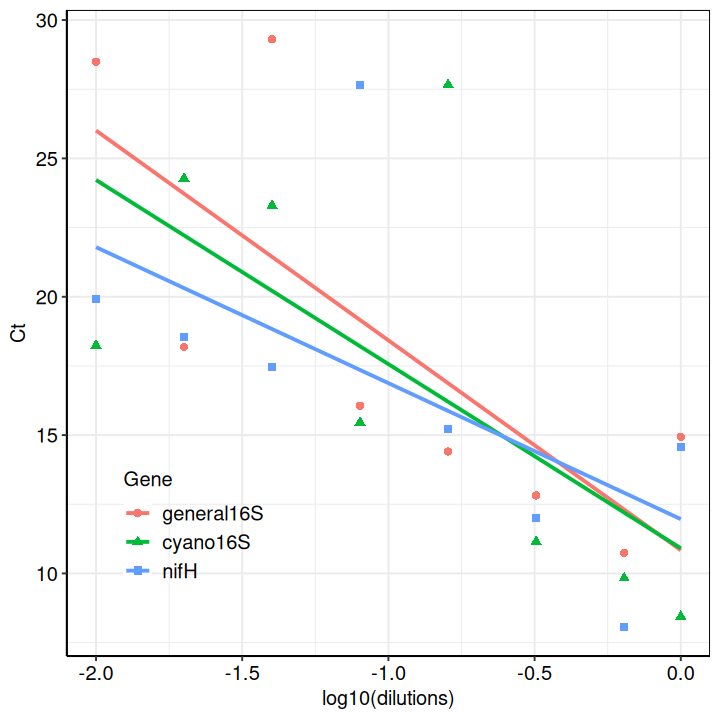

In [37]:
eff

There is a lot of noise in these, and the final efficiences are far from great (perfect would be 2.0). But the general correlation of decreasing concentration with increasing cycle number is correct in all genes, at least. And the nifH amplification is quite predictable, even if low. 

We add these efficiencies to our data:

In [38]:
qPCR['nifH'] <- eff$Efficiency[eff$Efficiency$Gene == 'nifH',"E"]
qPCR['cyano16s'] <- eff$Efficiency[eff$Efficiency$Gene == 'cyano16S',"E"]
qPCR['ref'] <- eff$Efficiency[eff$Efficiency$Gene == 'general16S',"E"]

We need to adjust our raw Ct values for nifH and cyano16s using our reference 16s Ct values. Since we have different PCR effeciencies, and low efficiencies, we use the generalized method for weighting our Ct values, which takes into account both the Ct values of the reference gene, and the different PCR efficiencies of both the target and reference genes. Details are [here](https://github.com/mirzaghaderi/rtpcr/blob/main/Method.md) and [here](https://doi.org/10.1186/s12859-017-1949-5). 

Using the rtpcr package, this has to be done one gene at a time:


In [39]:
nifHonly <- qPCR[, c("rock","moss","location","replicate","nifH","Ct_nifH","ref","Ct_ref")]
qPCR['nifH_wDCt'] <- compute_wDCt(
                       x=nifHonly,
                       block=NULL,
                       numOfFactors=3,
                       numberOfrefGenes=1, 
                       set_missing_target_Ct_to_40 = TRUE
                           )['wDCt']

In [40]:
cyano16Sonly <- qPCR[, c("rock","moss","location","replicate","cyano16s","Ct_cyano16s","ref","Ct_ref")]
qPCR['cyano16s_wDCt'] <- compute_wDCt(
                       x=cyano16Sonly,
                       block=NULL,
                       numOfFactors=3,
                       numberOfrefGenes=1, 
                       set_missing_target_Ct_to_40 = TRUE
                           )['wDCt']

These weighted Ct values of the target genes are theoretically independent of the general abundance of microbial and plant organelle DNA in the sample. 

<a id=interolate></a>
### Interpolating missing or erroneous wΔCt values

There is only one problem with these "corrected" wDCt values of our target genes - their accuracy is entirely dependent on the presence of a successful reference gene PCR amplification and its measurement. If there is no accompanying general 16S Ct data, our raw Ct values from nifH and cyanobacterial 16S are worthless, they are thrown out. And if the measurement of the reference gene Ct is weird, it affects the accuracy of the corresponding target gene wDCt values. 

A good example is sample `F09`, which has extremely low "corrected" wDCT for nifH and cyanobacterial 16S, indicating really, really high abundance of these genes in this sample, compared to others: 

In [41]:
head(qPCR)

,subsite,rock,moss,location,replicate,Ct_nifH,Ct_cyano16s,Ct_ref,nifH,cyano16s,ref,nifH_wDCt,cyano16s_wDCt
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B09,G01,G,DS,far,1,25.13721,16.26339,17.11365,1.597605,1.413337,1.354729,9.4946594,0.62129883
D09,G05,G,DS,far,2,22.97042,13.55746,15.57098,1.597605,1.413337,1.354729,8.7057940,-0.05355216
F09,G22,G,DS,far,3,25.02060,18.57098,39.36213,1.597605,1.413337,1.354729,-0.3290866,-7.97190157
H09,G23,G,DS,far,4,22.82162,13.37317,16.80852,1.597605,1.413337,1.354729,8.0631711,-0.68757884
A09,G01,G,DS,near,1,23.62055,14.69234,16.96503,1.597605,1.413337,1.354729,8.5346287,-0.09772166
C09,G05,G,DS,near,2,24.74349,16.62734,17.70571,1.597605,1.413337,1.354729,8.9692127,0.54362649


We can plot this as a positive value, Relative Expression [(see below)](#), to get an idea of how far out these "corrected" values are from the others

In [42]:
options(repr.plot.width = 20, repr.plot.height = 6)

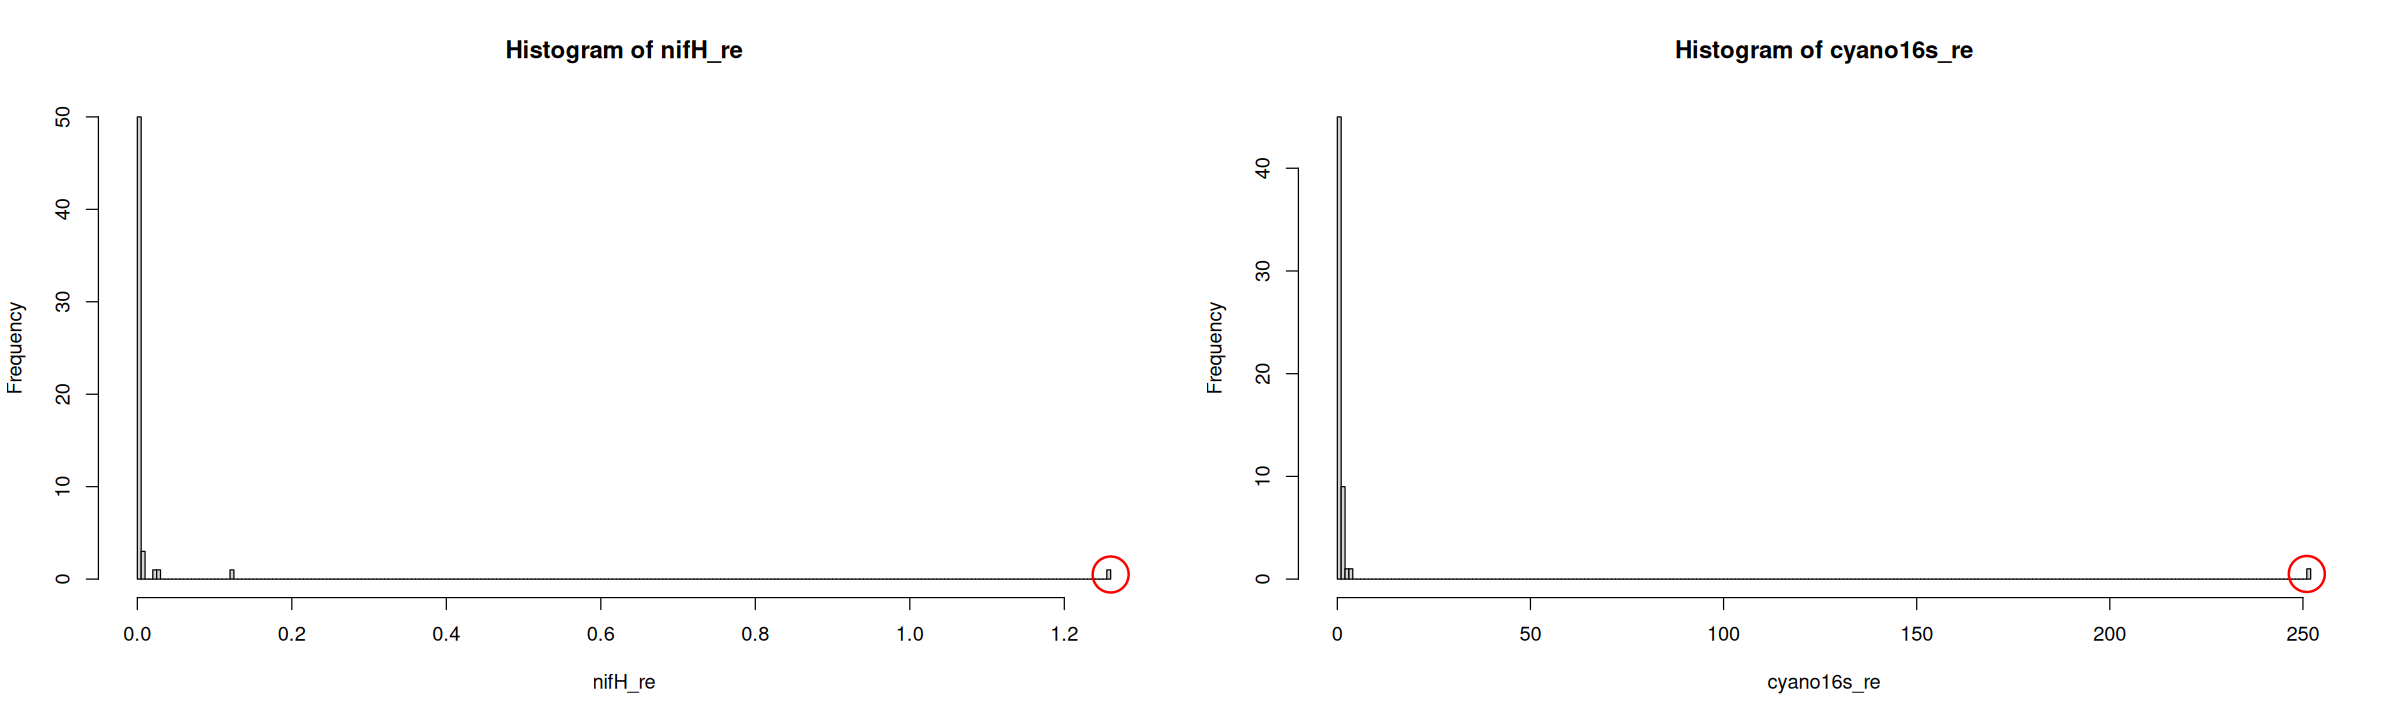

In [43]:
nifH_re <- 2^-(qPCR$nifH_wDCt)
cyano16s_re <- 2^-(qPCR$cyano16s_wDCt)

par(mfrow=c(1,2))
hist(nifH_re, breaks=300)
points(1.26,0.5, col="red", cex=4, lwd=2)
hist(cyano16s_re, breaks=300)
points(251,0.5, col="red", cex=4, lwd=2)

rm(nifH_re, cyano16s_re)


This is a clear outlier, in both the nifH and 16S abundances. The cause is an error in the reference gene used to weight this sample. Ct for our reference gene in this sample is 39.36, almost 40 cycles, meaning very low but non-zero abundance. The PCR reaction probably simply failed until late in the trial, when around 39 cycles amplification of contaminates probably began to appear. The Ct of the nifH and Cyanobacterial 16S are normal. So it's sort of like dividing by an incredibly small number, resulting in an astronomically, artificially high number.

In other cases, the 16S PCR simply failed to amplify at all. Given that our general 16S PCR amplifications had a high failure rate (20 reactions failed out of 76,  or 26% of our samples), we lose a lot of statistical power from this. 

But we just generated a lot of wDCt data, we can make a model now from our raw Ct values in each gene, and use it to interpolate the final wDCt in cases where we have inaccurate or missing reference gene Ct data, but good nifH or cyanobacterial 16S observations.  

In [58]:
## start with nifH 

## get rid of the outlier noticed above
qPCR_noOut <- qPCR[rownames(qPCR) != "F09",]

## make a model of wDCt from raw Ct
nifHfit <- lm(nifH_wDCt ~ Ct_nifH, data=qPCR_noOut)
## make some predictions of using our original Ct values
qPCR['nifH_wDCt_predicted'] <- predict(nifHfit, newdata=qPCR["Ct_nifH"]) 
## find the places where general 16S failed or gave unreliable results:
badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])

## make a new column, based on the experimental values, but plugging 
## interpolated values predicted from raw nifH_ct scores and
## our model in where necessary

## now with the ugliest old school R code possible, 
## plug in interpolated values
nifH_wDCt_interp <- qPCR['nifH_wDCt']
for (i in badGeneral16sRows){
  nifH_wDCt_interp[i,'nifH_wDCt'] <- qPCR[i,"nifH_wDCt_predicted"]
}

## add back into our data matrix
qPCR["nifH_wDCt_interp"] <- nifH_wDCt_interp['nifH_wDCt'] 

In [74]:
options(repr.plot.width = 20, repr.plot.height = 10)

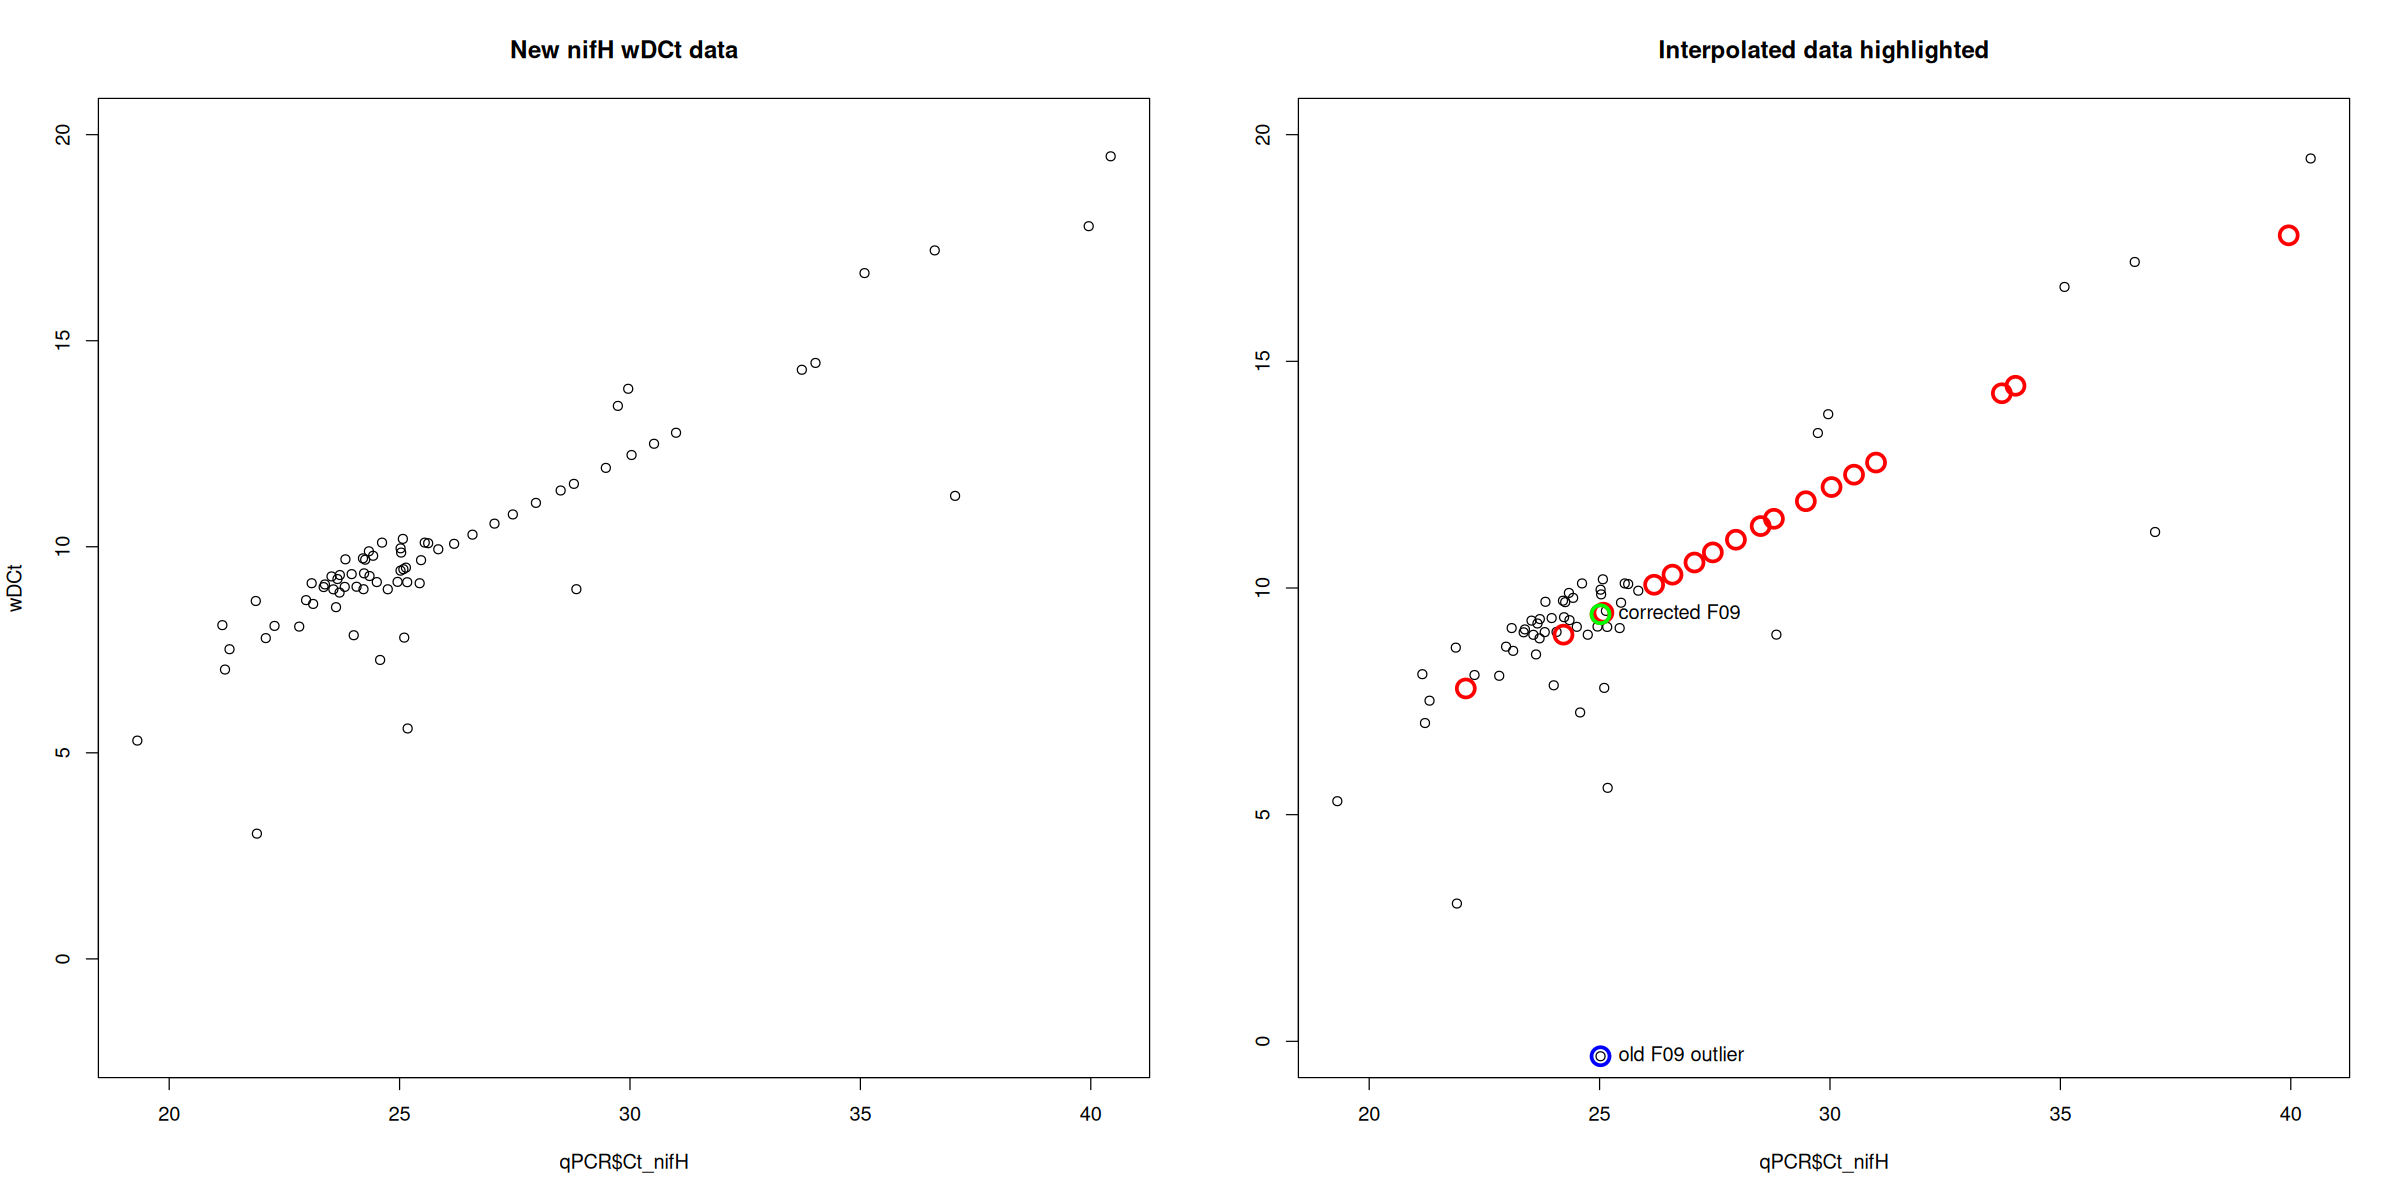

In [77]:
par(mfrow=c(1,2))
plot(qPCR$nifH_wDCt_interp ~ qPCR$Ct_nifH, main="New nifH wDCt data", ylab="wDCt", ylim=c(-2,20))
plot(qPCR$nifH_wDCt ~ qPCR$Ct_nifH, main="Interpolated data highlighted", ylab="",ylim=c(0,20))
#abline(lm(qPCR_noOut$nifH_wDCt ~ qPCR_noOut$Ct_nifH), lty=3)
points(x=qPCR[badGeneral16sRows,"Ct_nifH"],
       y=qPCR[badGeneral16sRows,"nifH_wDCt_interp"],
       col="red",
       cex=2,
       lwd=3,
       )
points(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt_interp"],
       col="green",
       cex=2,
       lwd=3,
       )
text(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt_interp"],
       pos="4",
       offset=0.75,
       labels="corrected F09"
       )
points(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt"],
       col="blue",
       cex=2,
       lwd=3,
       )
text(x=qPCR["F09","Ct_nifH"],
       y=qPCR["F09","nifH_wDCt"],
       pos="4",
       offset=0.75,
       labels="old F09 outlier"
       )


These look like reasonable estimates of what the wΔCt should be from these raw Ct values. It is a tough decision, to interpolate or not, because they samples may have been different based on the behaviour of the housekeeping gene (general 16S) in these samples. Anyway, we will try using these values going forward. Repeat the process with cyanobacterial 16S genes.

In [71]:
qPCR_noOut <- qPCR[rownames(qPCR) != "F09",]

badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])
cyano16sfit <- lm(cyano16s_wDCt ~ Ct_cyano16s, data=qPCR_noOut)
qPCR['cyano16s_wDCt_predicted'] <- predict(cyano16sfit, newdata=qPCR["Ct_cyano16s"])

badGeneral16sRows <- rownames(qPCR[is.na(qPCR$Ct_ref) | qPCR$Ct_ref > 35,])

In [81]:
cyano16s_wDCt_interp <- qPCR['cyano16s_wDCt']
for (i in badGeneral16sRows){
  cyano16s_wDCt_interp[i,"cyano16s_wDCt"] <- qPCR[i,"cyano16s_wDCt_predicted"]
}
qPCR["cyano16s_wDCt_interp"] <- cyano16s_wDCt_interp ## add to our data matrix

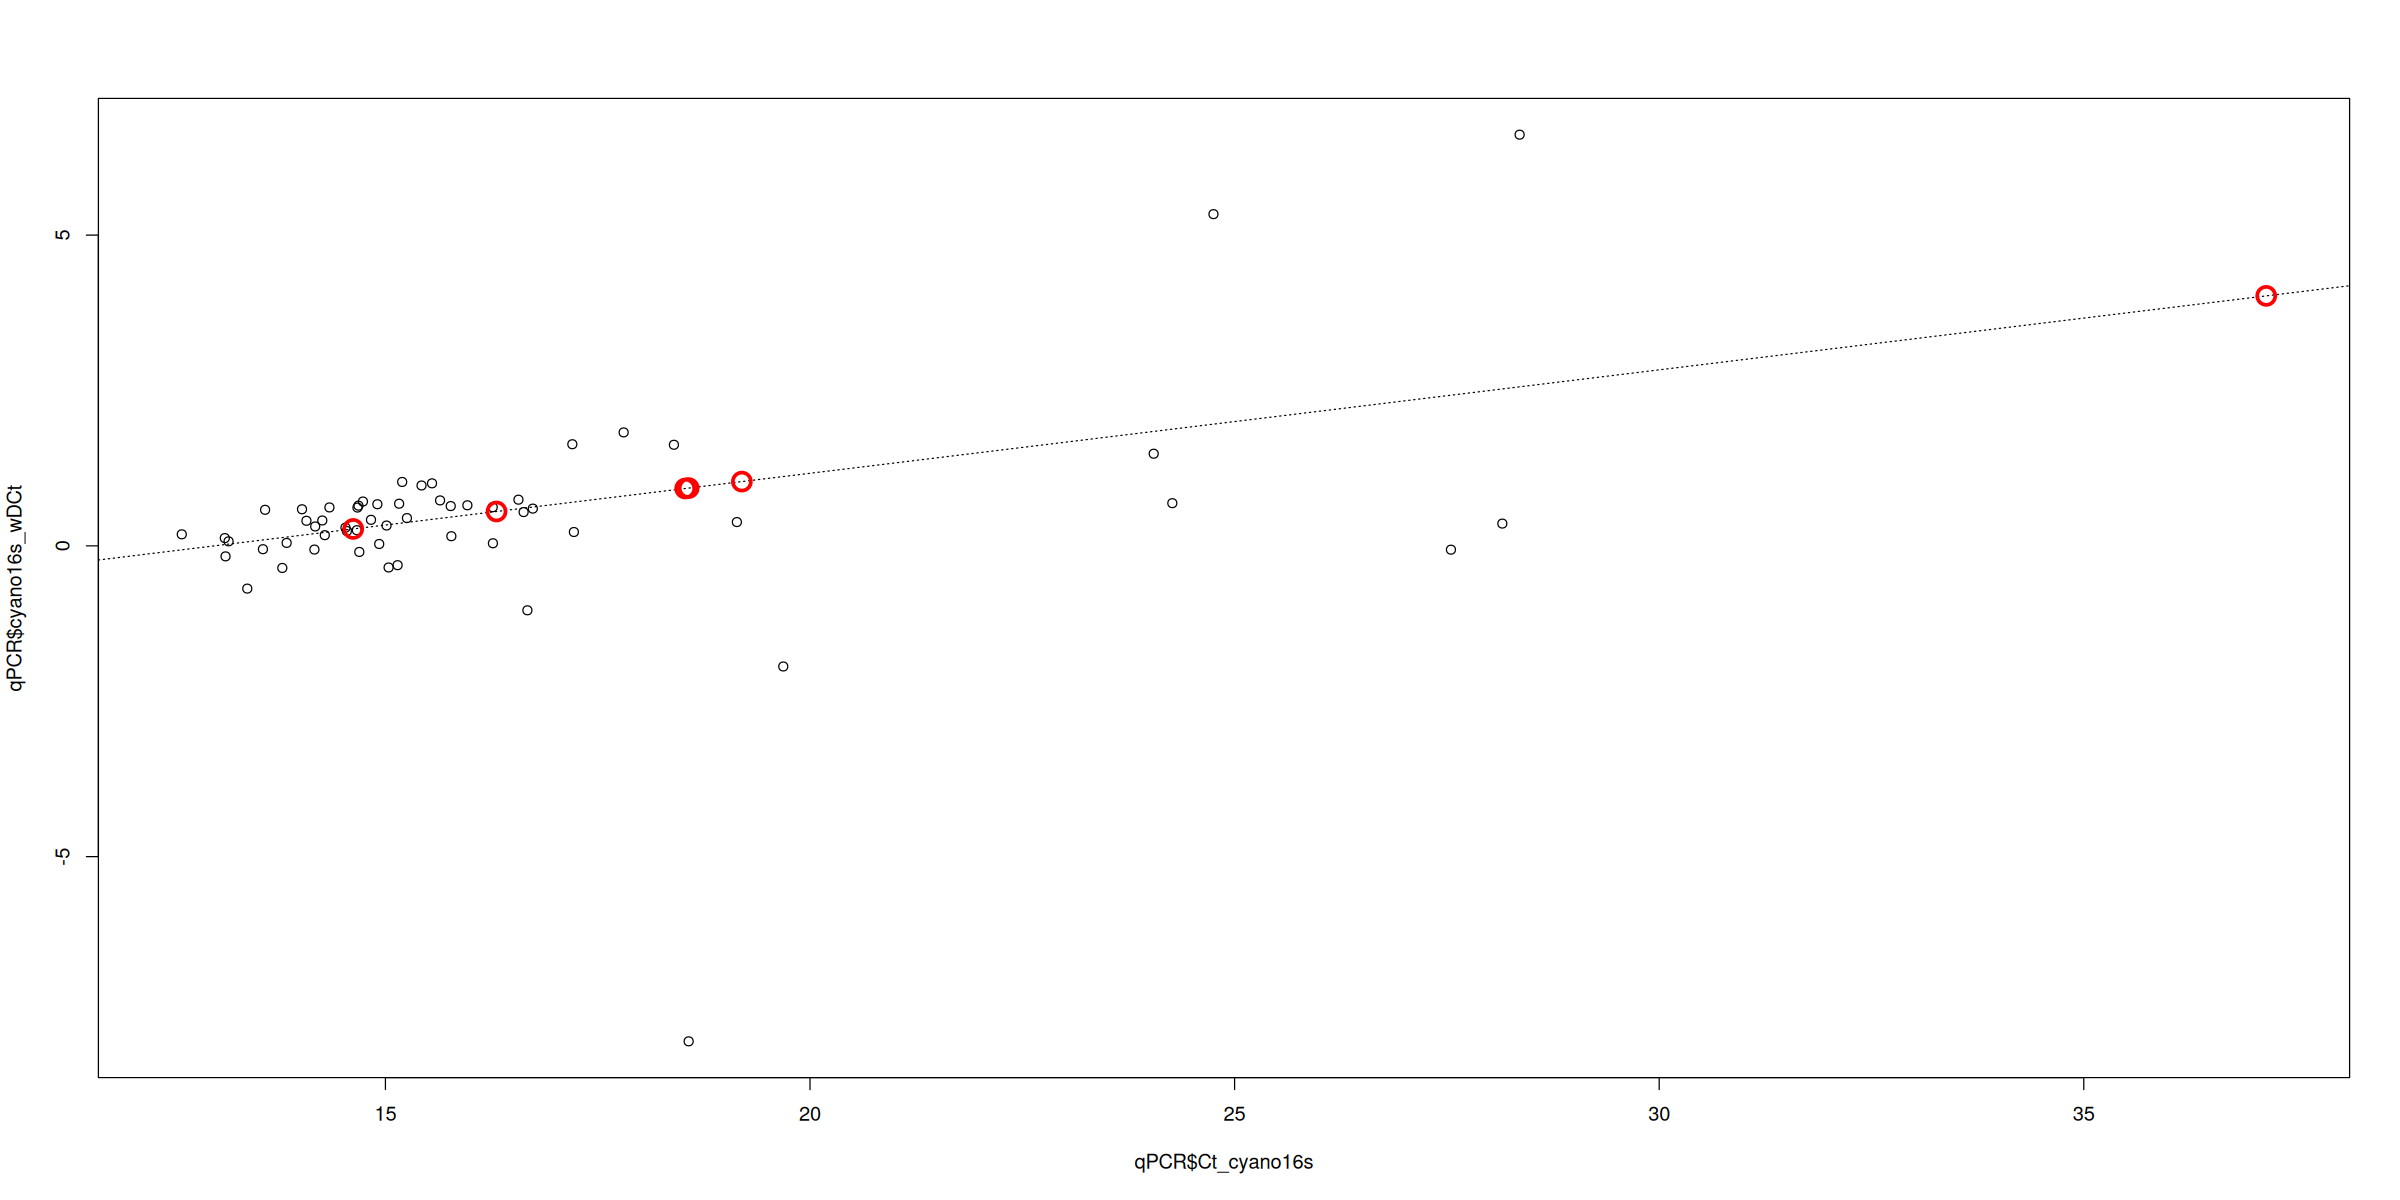

In [83]:
plot(qPCR$cyano16s_wDCt ~ qPCR$Ct_cyano16s)
abline(lm(qPCR_noOut$cyano16s_wDCt ~ qPCR_noOut$Ct_cyano16s), lty=3)
points(x=qPCR[badGeneral16sRows,"Ct_cyano16s"],
       y=qPCR[badGeneral16sRows,"cyano16s_wDCt_interp"],
       col="red",
       cex=2,
       lwd=3,
       )


Looks reasonable. We don't recover as much data as we did with nifH above, but this is because cyanobacterial qPCR reactions also failed at a high rate (14 reactions out of 76, 18%). 

<a id=RE></a>
### Relative Expression and log transformation

These modified Ct values, now called wDCt, can be used to back-calculate to "relative expression", which is a unit-less value that showed be directly (linearly) related to how many copies of the target gene were originally present in the DNA in each sample, but independent of the patterns of general abundance of microbial and plant organelle DNA in the sample. The calculation is really simple:

In [84]:
qPCR["nifH_RE"] <- 2^-(qPCR["nifH_wDCt_interp"])

qPCR['cyano16s_RE'] <- 2^-(qPCR["cyano16s_wDCt_interp"])

We can remove the abundances of nifH and cyanobacterial 16S that were observed in our pure-water control samples, as anything in these was just noise or lab contamination:

In [85]:
## get the larger RE of our two water-only samples
nifH_RE_control <- max(qPCR[qPCR$subsite=="NTC","nifH_RE"])
## subtract all RE values by this
qPCR["nifH_RE_corrected"] <- qPCR["nifH_RE"] - nifH_RE_control
## set negatives equal to zero.
qPCR$nifH_RE_corrected[qPCR$nifH_RE_corrected < 0] <- 0

In [86]:
## cyano16s
cyano16s_RE_control <- max(qPCR[qPCR$subsite=="NTC",'cyano16s_RE'] )
qPCR["cyano16s_RE_corrected"] <- qPCR["cyano16s_RE"] - cyano16s_RE_control
qPCR$cyano16s_RE_corrected[qPCR$cyano16s_RE_corrected < 0] <- 0

These REs should now be comparable among samples to ask some ecological questions. Let's save a simpler, cleaner version of this dataframe for the analyses below:

In [174]:
qPCRres <- qPCR[qPCR$subsite != "NTC", c("subsite","rock","moss","location","nifH_RE_corrected","cyano16s_RE_corrected")]

<a id=ecoNifH><a>
## NifH abundances - ecological predictors

<a id=nifHnearFar></a>
### Proximity to fern rhizomes

In [109]:
options(repr.plot.width = 20, repr.plot.height = 10)

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”


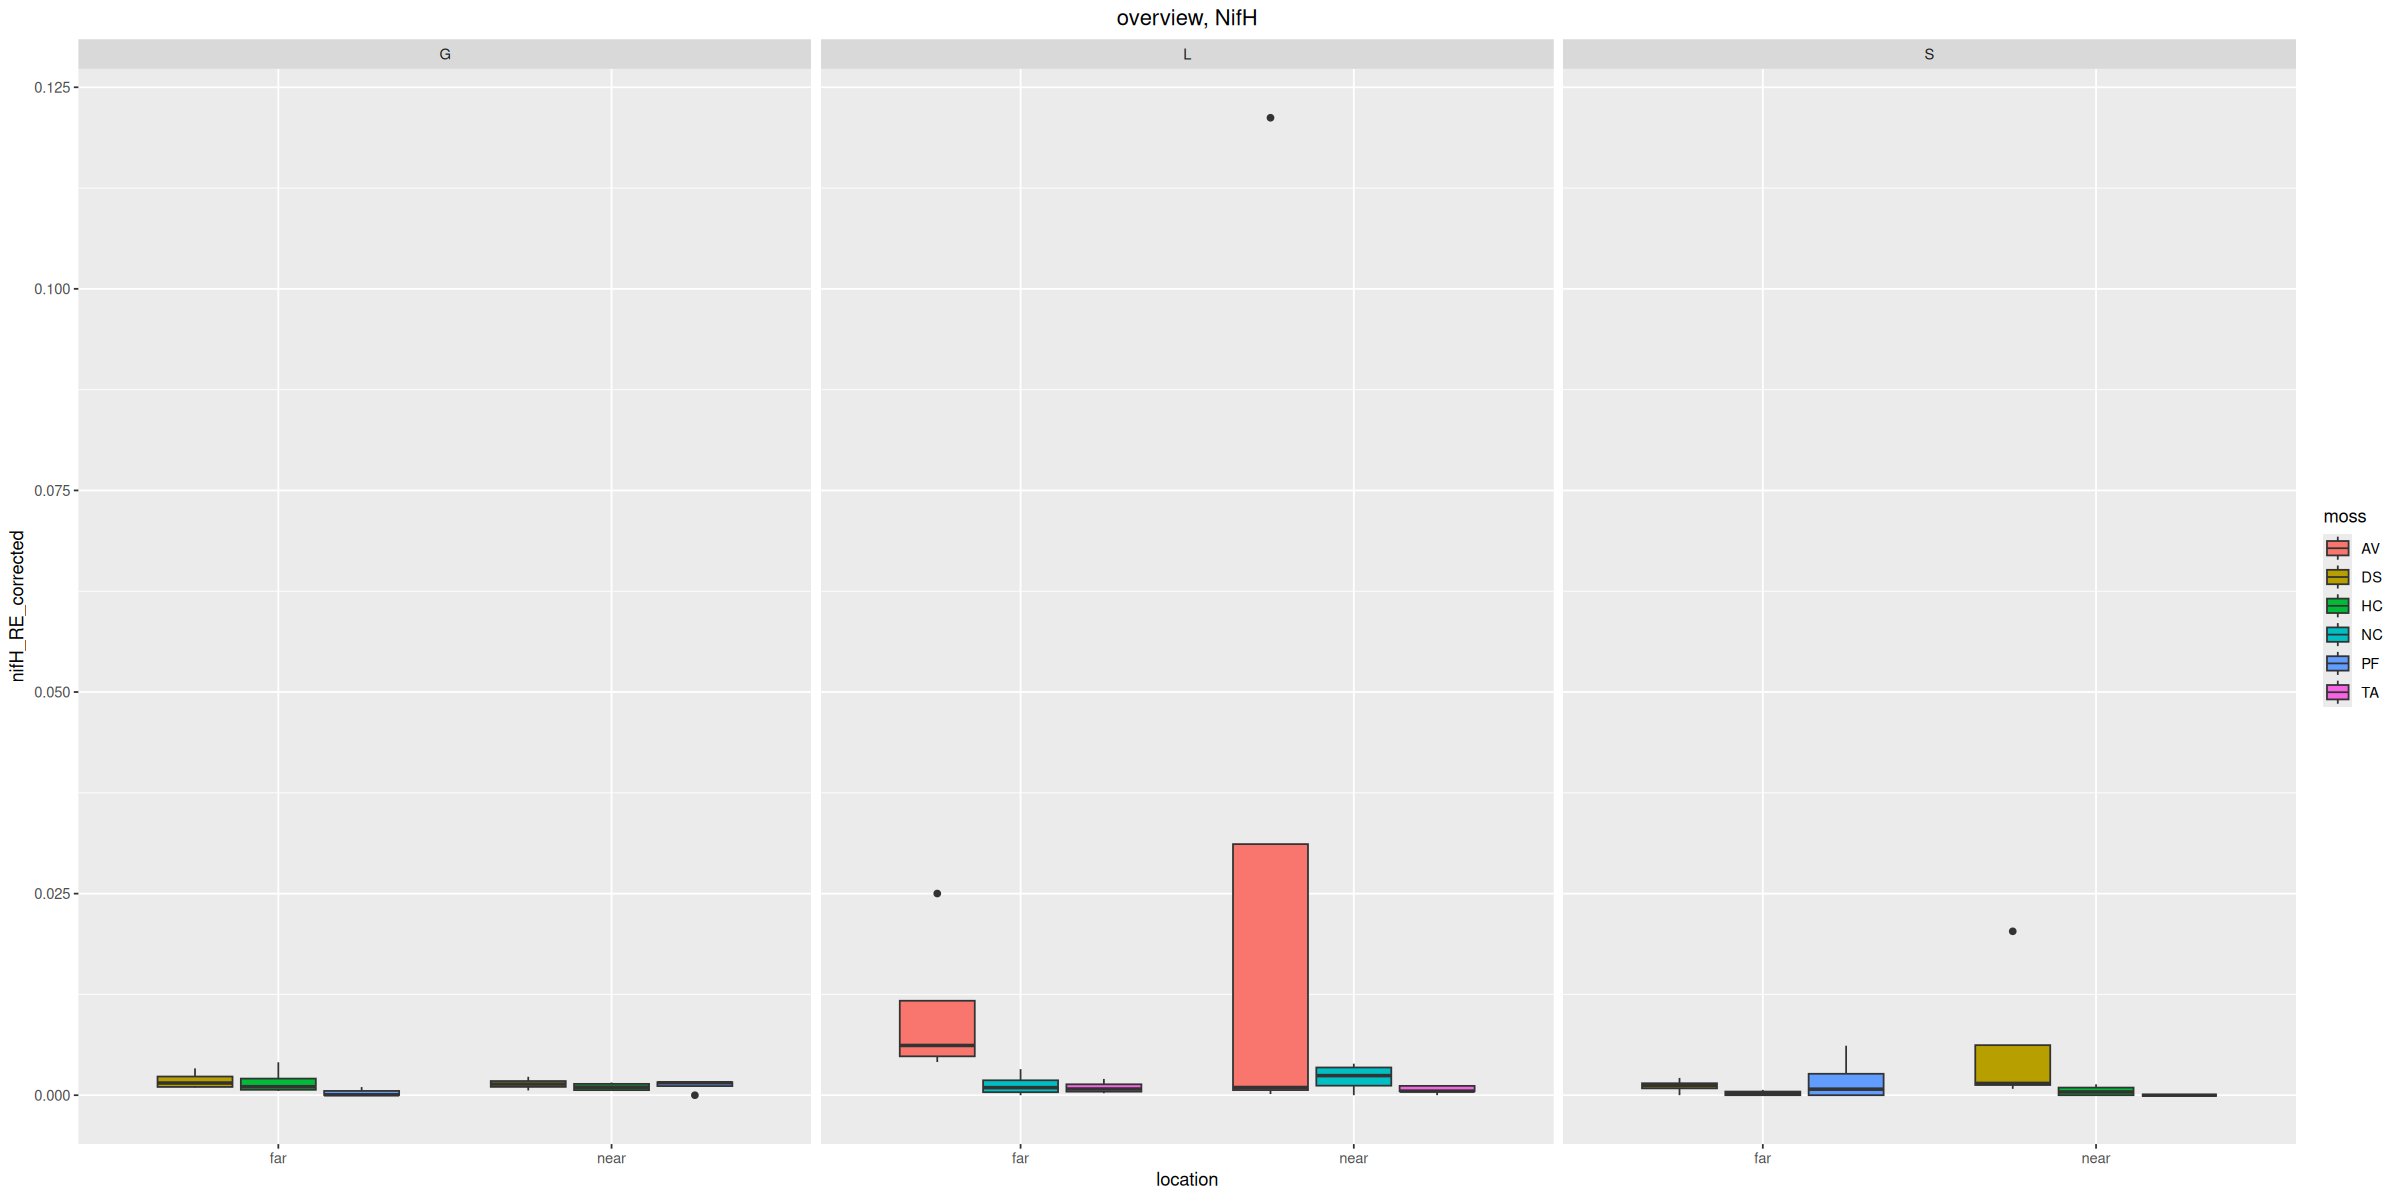

In [110]:
qPCRres <- read.csv("qPCRresults.csv", row.names=1)
nifH_overview <- ggplot(qPCRres, aes(x=location, y=nifH_RE_corrected, fill=moss)) + 
                        geom_boxplot() + 
                        facet_grid(. ~ rock) +
                        ggtitle("overview, NifH") + 
                        theme(plot.title = element_text(hjust = 0.5))
nifH_overview 


Zoom in a little past the outliers:

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”


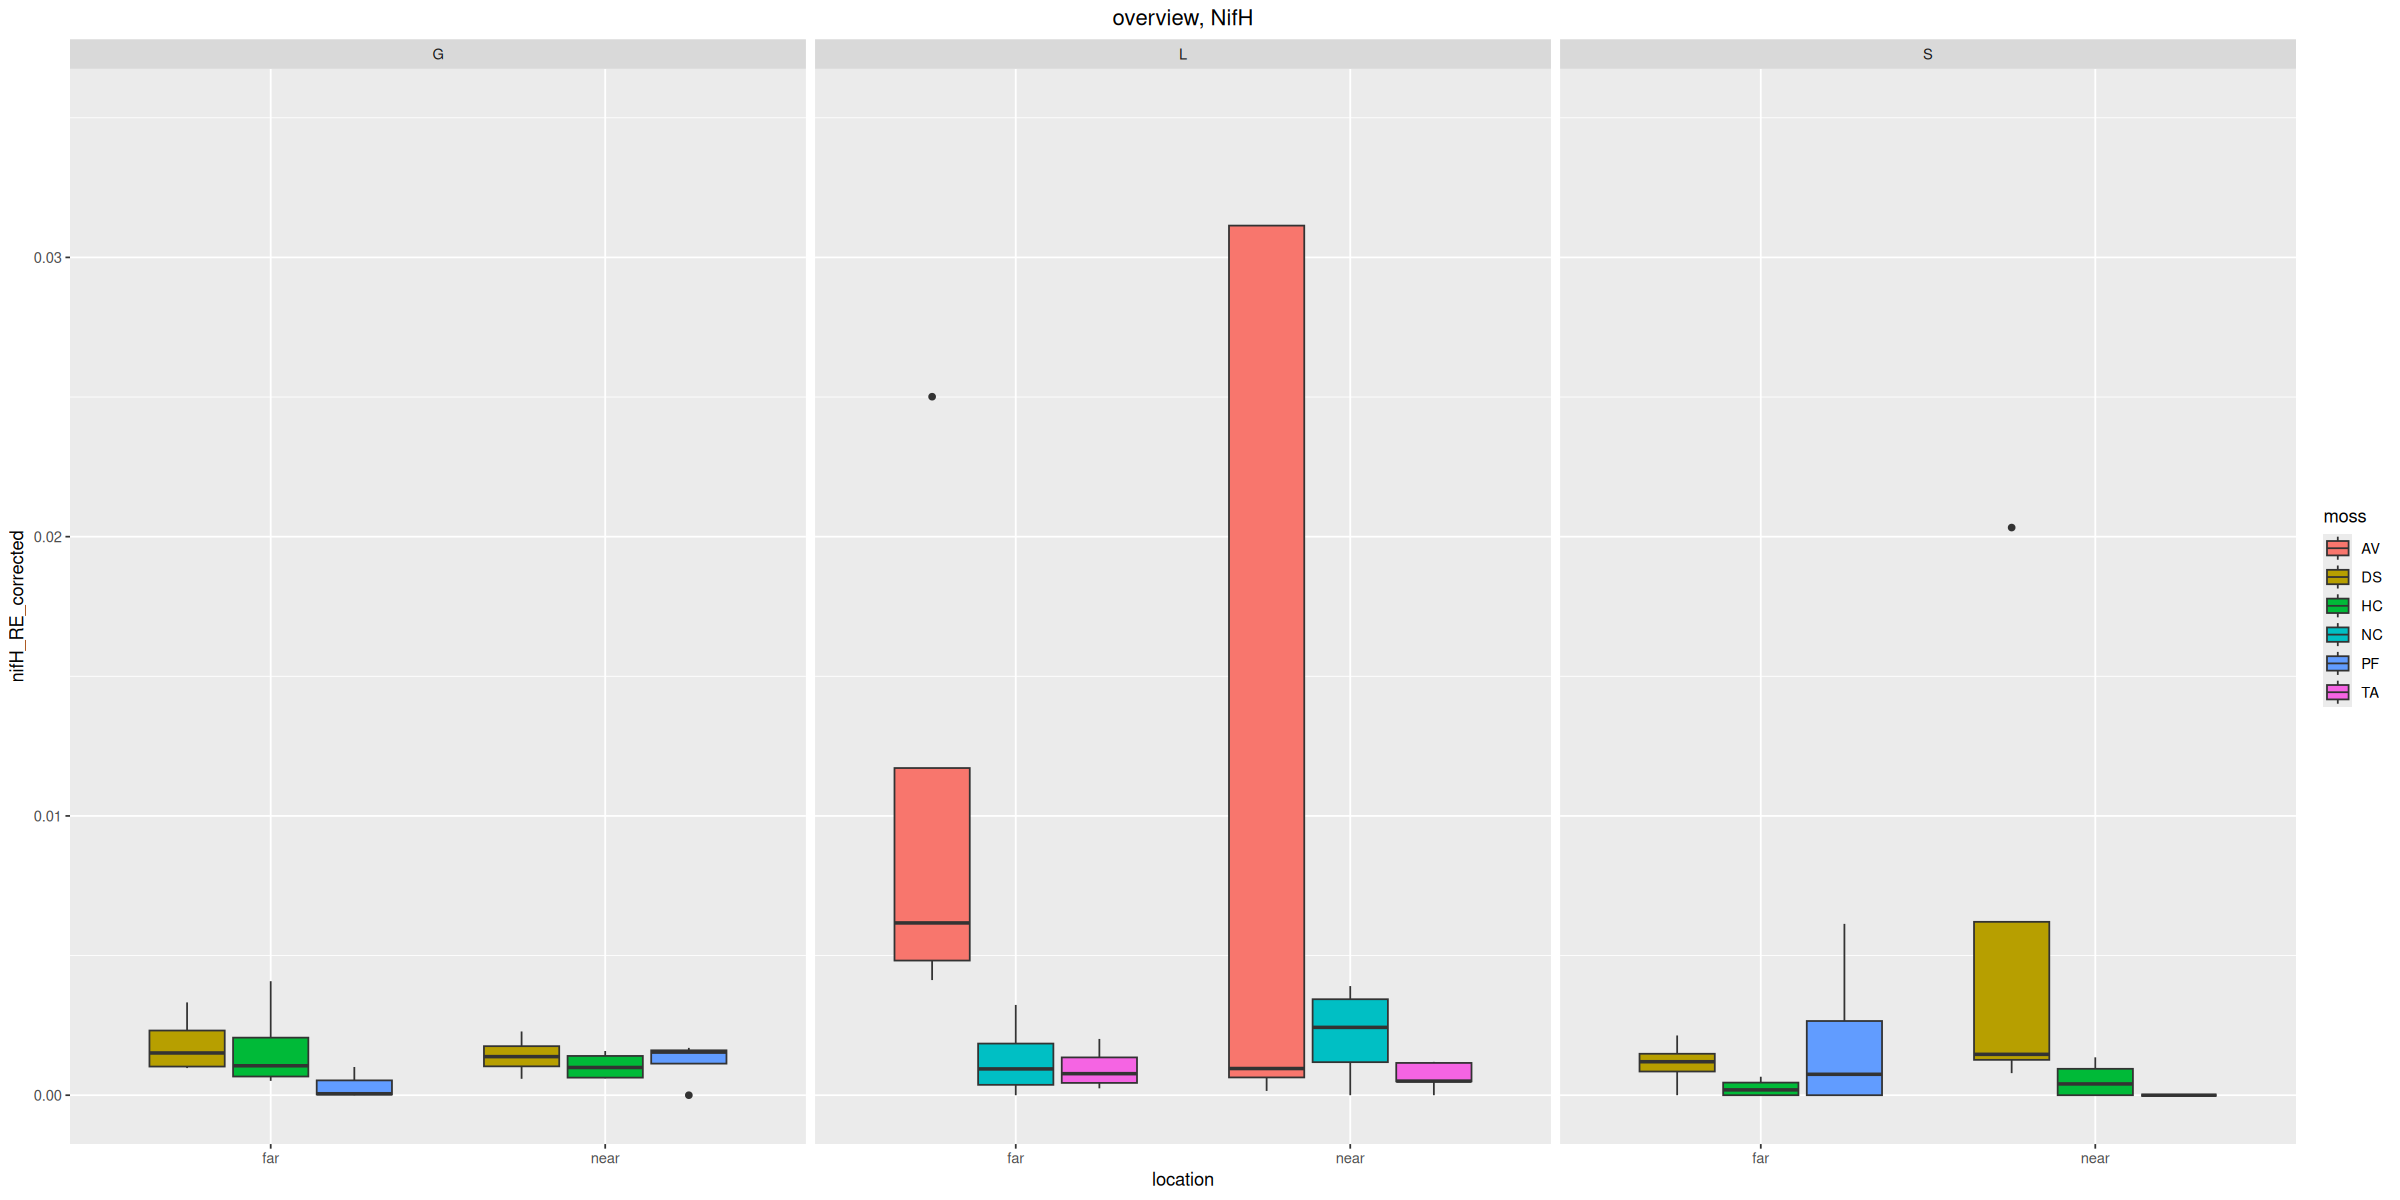

In [92]:
nifH_overview + coord_cartesian(ylim=c(0, .035))

I see no pattern, concerning proximity to fern rhizomes. But we can check with some models. Perhaps the first, simplest test is a paired t-test among all samples, regardless of rock type or moss type.

In [99]:
options(repr.plot.width =5, repr.plot.height = 5)


	Bartlett test of homogeneity of variances

data:  qPCRres$nifH_RE_corrected by qPCRres$location
Bartlett's K-squared = 61.943, df = 1, p-value = 3.536e-15


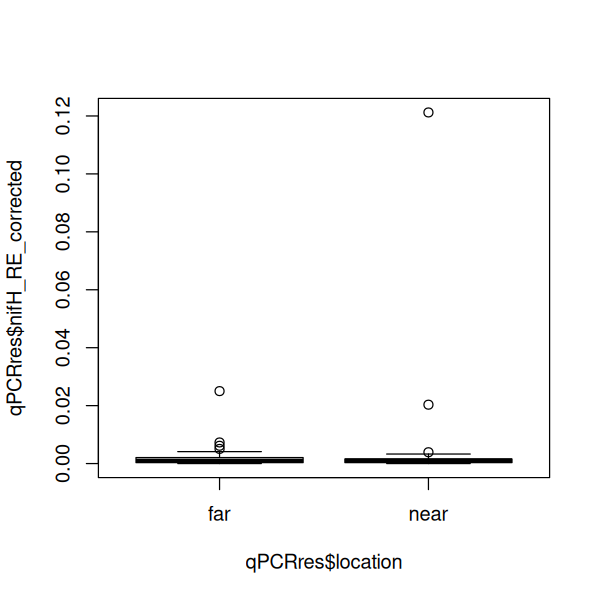

In [100]:
near_nifH_RE <- qPCRres[qPCRres$location == "near","nifH_RE_corrected"]
far_nifH_RE <- qPCRres[qPCRres$location == "far","nifH_RE_corrected"]
boxplot(qPCRres$nifH_RE_corrected ~ qPCRres$location) ## slighter higher RE in near samples
bartlett.test(qPCRres$nifH_RE_corrected ~ qPCRres$location)

Definitely different variances. But data are paired in near/far sets...

In [98]:
t.test(x=near_nifH_RE,y=far_nifH_RE,
       alternative = "greater",
       mu = 0, 
       paired = TRUE,
       var.equal = FALSE,
       conf.level = 0.95)


	Paired t-test

data:  near_nifH_RE and far_nifH_RE
t = 0.81097, df = 34, p-value = 0.2115
alternative hypothesis: true mean difference is greater than 0
95 percent confidence interval:
 -0.002990595          Inf
sample estimates:
mean difference 
    0.002756128 


Not significantly different. If we make a model that takes rock type or moss type into consideration? I don't think we can really do both, because some moss types only occurred on certain rock types. Makes for singularity. Much like my other hobbies.

Checking for near/far effect by moss, with moss as a random effect:

In [101]:
summary(lmerTest::lmer(nifH_RE_corrected  ~ location  + (location|moss), data = qPCRres))

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: nifH_RE_corrected ~ location + (location | moss)
   Data: qPCRres

REML criterion at convergence: -390.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7387 -0.1324 -0.0708 -0.0183  7.3057 

Random effects:
 Groups   Name         Variance  Std.Dev. Corr 
 moss     (Intercept)  9.267e-06 0.003044      
          locationnear 4.532e-05 0.006732 1.00 
 Residual              1.792e-04 0.013386      
Number of obs: 72, groups:  moss, 6

Fixed effects:
             Estimate Std. Error       df t value Pr(>|t|)
(Intercept)  0.002579   0.002560 8.533627   1.008    0.341
locationnear 0.003488   0.004202 5.636349   0.830    0.440

Correlation of Fixed Effects:
            (Intr)
locationner -0.139
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


And rock type:

In [102]:
summary(lmerTest::lmer(nifH_RE_corrected  ~ location  + (location|rock), data = qPCRres))

boundary (singular) fit: see help('isSingular')

Warning message:
“Model failed to converge with 1 negative eigenvalue: -8.4e-01”


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: nifH_RE_corrected ~ location + (location | rock)
   Data: qPCRres

REML criterion at convergence: -386

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.4700 -0.2228 -0.1464 -0.0723  7.8841 

Random effects:
 Groups   Name         Variance  Std.Dev. Corr 
 rock     (Intercept)  0.000e+00 0.000000      
          locationnear 9.023e-06 0.003004  NaN 
 Residual              2.105e-04 0.014510      
Number of obs: 72, groups:  rock, 3

Fixed effects:
              Estimate Std. Error        df t value Pr(>|t|)
(Intercept)   0.002214   0.002418 67.675094   0.916    0.363
locationnear  0.002603   0.003836  4.414340   0.678    0.531

Correlation of Fixed Effects:
            (Intr)
locationner -0.630
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


Great, sampler didn't even converge. And both models are complaining about singularity. I don't know why, as near/far categories are evenly distributed across rock types and moss types. Try a good old-fashioned non-mixed model:

In [103]:
summary(lm(nifH_RE_corrected  ~ location  + moss + rock, data = qPCRres))


Call:
lm(formula = nifH_RE_corrected ~ location + moss + rock, data = qPCRres)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.021789 -0.002110 -0.000381  0.000886  0.099277 

Coefficients: (1 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.019246   0.005168   3.724 0.000417 ***
locationnear  0.002695   0.003270   0.824 0.412991    
mossDS       -0.018269   0.006344  -2.880 0.005405 ** 
mossHC       -0.019984   0.006344  -3.150 0.002480 ** 
mossNC       -0.018859   0.006934  -2.720 0.008396 ** 
mossPF       -0.019902   0.006477  -3.072 0.003117 ** 
mossTA       -0.019776   0.006578  -3.007 0.003772 ** 
rockL               NA         NA      NA       NA    
rockS         0.000541   0.004092   0.132 0.895226    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01387 on 64 degrees of freedom
  (2 observations deleted due to missingness)
Multiple R-squared:  0.1843,

----------------------------------------------------

Rock is adding nothing to the model. Remove:

In [104]:
summary(lm(nifH_RE_corrected  ~ location  + moss, data = qPCRres))


Call:
lm(formula = nifH_RE_corrected ~ location + moss, data = qPCRres)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.021782 -0.002220 -0.000501  0.000903  0.099285 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.019254   0.005129   3.754 0.000374 ***
locationnear  0.002680   0.003244   0.826 0.411722    
mossDS       -0.017998   0.005959  -3.020 0.003607 ** 
mossHC       -0.019714   0.005959  -3.308 0.001533 ** 
mossNC       -0.018859   0.006881  -2.741 0.007907 ** 
mossPF       -0.019631   0.006099  -3.219 0.002011 ** 
mossTA       -0.019776   0.006528  -3.030 0.003512 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01376 on 65 degrees of freedom
  (2 observations deleted due to missingness)
Multiple R-squared:  0.184,	Adjusted R-squared:  0.1087 
F-statistic: 2.443 on 6 and 65 DF,  p-value: 0.03423


Basically, nifH abundances are different, mostly due to the high abundance of nifH in the moss <i>Anomodon viticulosus</i>. But even given this, we don't find that location is that important as a predictor. 

<a id=nifHrockMoss></a>
### Rock type and Moss species

The above models point to moss species as the most important predictor. Let's look a little closer:

In [111]:
qPCRres <- read.csv("qPCRresults.csv", row.names=1)

In [115]:
options(repr.plot.width = 20, repr.plot.height = 15)

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Remo

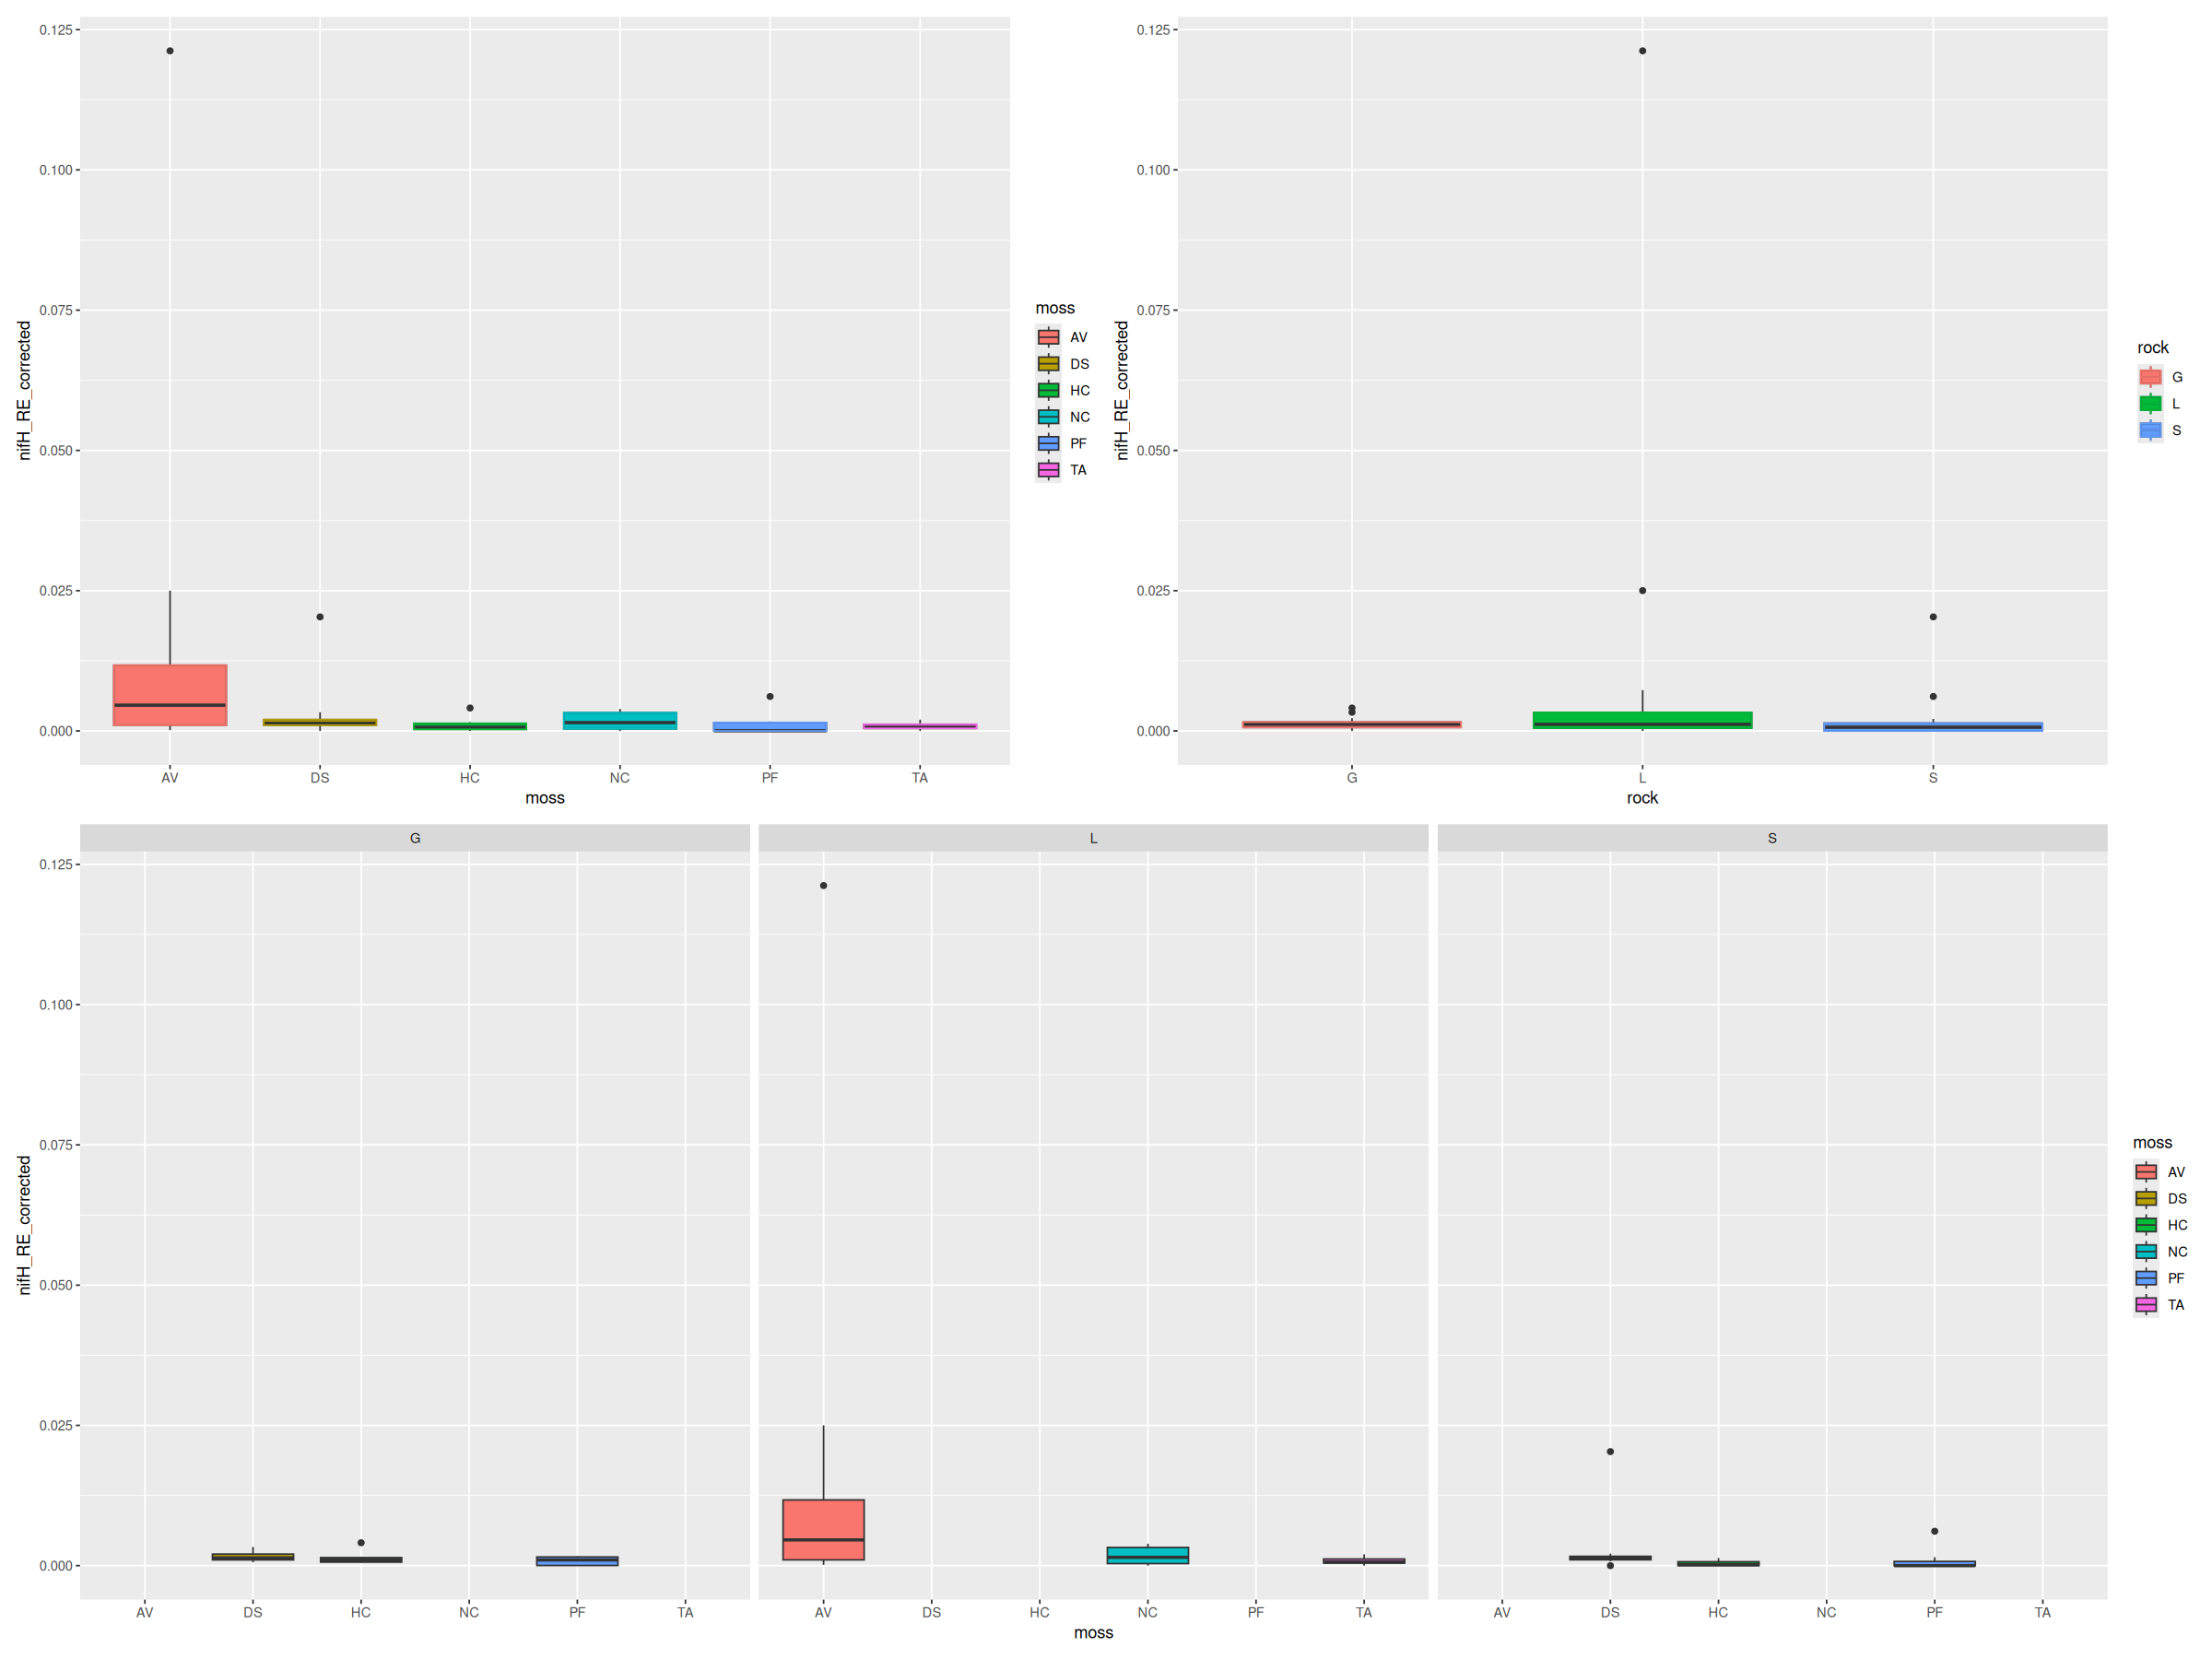

In [116]:
nifH_moss_box <- ggplot(qPCRres, aes(x=moss, y=nifH_RE_corrected, fill=moss)) +
                        geom_boxplot() +
                        geom_boxplot(aes(col=moss), fatten=NULL, fill=NA,
                                     coef=0, outlier.shape=NA,show.legend = F)

nifH_rock_box <- ggplot(qPCRres, aes(x=rock, y=nifH_RE_corrected, fill=rock)) +
                        geom_boxplot() +
                        geom_boxplot(aes(col=rock), fatten=NULL, fill=NA,
                                     coef=0, outlier.shape=NA,show.legend = T)


nifH_rock_moss_box <- ggplot(qPCRres, aes(x=moss, y=nifH_RE_corrected, fill=moss)) +
                        geom_boxplot() +
                        facet_grid(. ~ rock)

 (nifH_moss_box | nifH_rock_box) / nifH_rock_moss_box

If we want to zoom in a bit:

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Remo

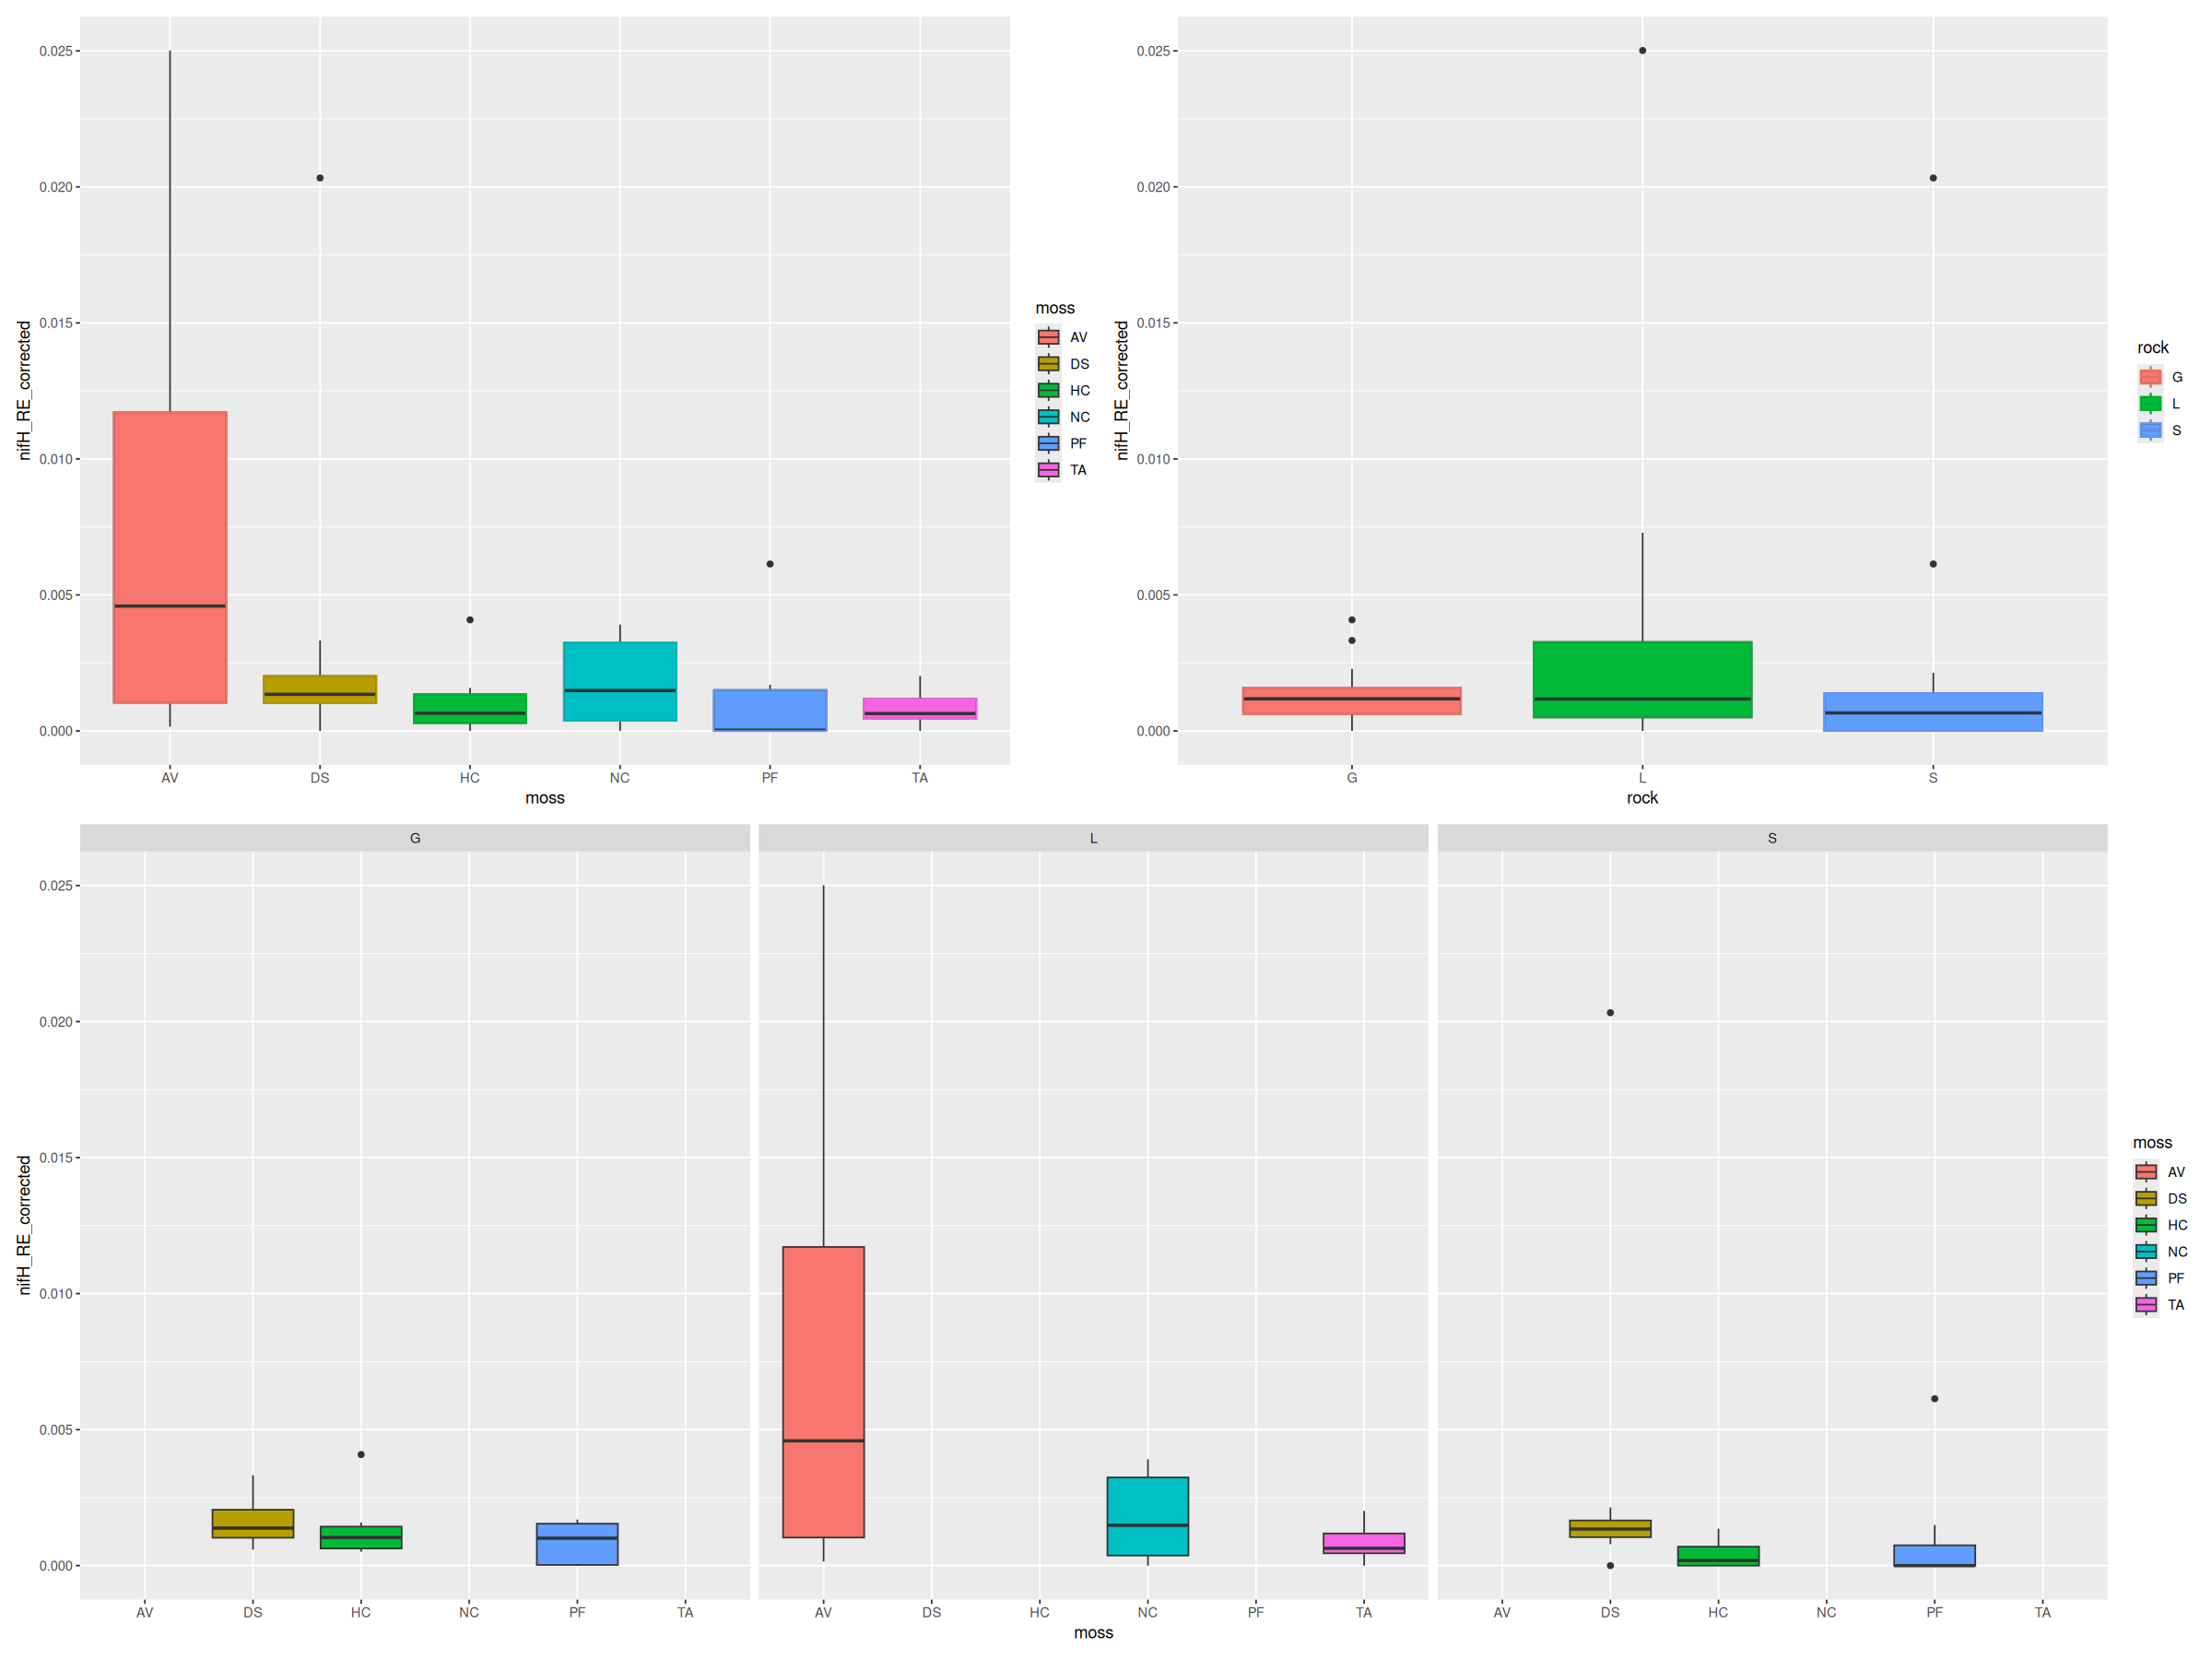

In [118]:
ylimi <- 0.025
nifH_moss_box_zoom <- nifH_moss_box +
                      coord_cartesian(ylim=c(0, ylimi)) 
nifH_rock_box_zoom <- nifH_rock_box +
                      coord_cartesian(ylim=c(0, ylimi)) 
nifH_rock_moss_box_zoom <- nifH_rock_moss_box +
                           coord_cartesian(ylim=c(0, ylimi)) 
nifH_all_zoom <- (nifH_moss_box_zoom | nifH_rock_box_zoom) / nifH_rock_moss_box_zoom
nifH_all_zoom

As we saw above, the mixed model approach isn't really viable, due to the fact that certain moss species are only associated with one rock or another. These data don't seem entirely "normal", but we can try a general classical regression model:

In [123]:
summary(lm(nifH_RE_corrected  ~ moss + rock, data = qPCRres))


Call:
lm(formula = nifH_RE_corrected ~ moss + rock, data = qPCRres)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.020442 -0.001211 -0.000501  0.000348  0.100625 

Coefficients: (1 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0205939  0.0048906   4.211 7.99e-05 ***
mossDS      -0.0182101  0.0063274  -2.878  0.00541 ** 
mossHC      -0.0199255  0.0063274  -3.149  0.00247 ** 
mossNC      -0.0188588  0.0069163  -2.727  0.00821 ** 
mossPF      -0.0198433  0.0064610  -3.071  0.00311 ** 
mossTA      -0.0197764  0.0065614  -3.014  0.00367 ** 
rockL               NA         NA      NA       NA    
rockS        0.0004238  0.0040790   0.104  0.91757    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01383 on 65 degrees of freedom
  (2 observations deleted due to missingness)
Multiple R-squared:  0.1756,	Adjusted R-squared:  0.09951 
F-statistic: 2.308 on 6 and 65 DF, 

Same as above. It really is moss species, and especially <i>Anomodon viticulosus</i> driving differences. This notebook is already long and confusing, so I won't include the model with interactions between moss and rock for nifH, but it is the same, no really important or strong interaction effects are evident, especially since we can't really track the behaviour of nifH in <i>Anomodon</i> outside of the limestone. 

Taking an ANOVA approach:

In [120]:
nifH_moss_rock_model_noInt <- aov(nifH_RE_corrected ~ moss + rock, qPCRres)
summary(nifH_moss_rock_model_noInt)

            Df   Sum Sq   Mean Sq F value Pr(>F)  
moss         5 0.002647 0.0005295   2.767 0.0251 *
rock         1 0.000002 0.0000021   0.011 0.9176  
Residuals   65 0.012437 0.0001913                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

Checking the interactions, which I don't really trust due to issue of rock-associated moss species:

In [122]:
nifH_moss_rock_model_int <- aov(nifH_RE_corrected ~  moss + rock + moss:rock, qPCRres)
summary(nifH_moss_rock_model_int)

            Df   Sum Sq   Mean Sq F value Pr(>F)  
moss         5 0.002647 0.0005295   2.686 0.0291 *
rock         1 0.000002 0.0000021   0.010 0.9188  
moss:rock    2 0.000017 0.0000086   0.043 0.9576  
Residuals   63 0.012420 0.0001971                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [125]:
TukeyHSD(nifH_moss_rock_model_noInt, conf.level=.95)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = nifH_RE_corrected ~ moss + rock, data = qPCRres)

$moss
               diff         lwr           upr     p adj
DS-AV -1.799824e-02 -0.03558667 -0.0004098074 0.0419231
HC-AV -1.971360e-02 -0.03730203 -0.0021251683 0.0192447
NC-AV -1.885880e-02 -0.03916817  0.0014505732 0.0836421
PF-AV -1.963141e-02 -0.03763374 -0.0016290784 0.0246866
TA-AV -1.977636e-02 -0.03904352 -0.0005091994 0.0409307
HC-DS -1.715361e-03 -0.01607625  0.0126455322 0.9992690
NC-DS -8.605590e-04 -0.01844899  0.0167278712 0.9999910
PF-DS -1.633173e-03 -0.01649811  0.0132317636 0.9995133
TA-DS -1.778122e-03 -0.01815206  0.0145958157 0.9995402
NC-HC  8.548019e-04 -0.01673363  0.0184432321 0.9999913
PF-HC  8.218785e-05 -0.01478275  0.0149471245 1.0000000
TA-HC -6.276080e-05 -0.01643670  0.0163111766 1.0000000
PF-NC -7.726141e-04 -0.01877495  0.0172297182 0.9999953
TA-NC -9.175627e-04 -0.02018472  0.0183495973 0.9999922
TA-PF -1.

Etc, etc. All the mosses are different to <i>Anomodon</i> but we can't tell if they are different to each other.
Generally, I think the take aways are that many of these mosses contained non-zero nifH abundances, over and above the expected levels of homologous genes from plant tissue. Our best ecological predictor is moss species, as one moss seem to host more nitrogen-fixation capability than others. 

<a id=ecoCyano16s><a>
## Cyanobacterial 16S rRNA abundances - ecological predictors

We treated the nifH abundances above as a continuous variable for the measure of the potential for nitrogen fixation by cyanobacteria. The cyanobacterial 16S rRNA gene was intended to be used differently, more as a measure of the presence and abundance of cyanobacteria generally. Its behavior in the data shown below fits this pattern, with lots of zeroes and non-normally distributed non-zero values.  We will mostly treat it more as pseudo-count than as a continuous variable.

<a id=cyano16sNearFar></a>
### Proximity to fern rhizomes

In [132]:
options(repr.plot.width = 20, repr.plot.height = 8)

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`).”


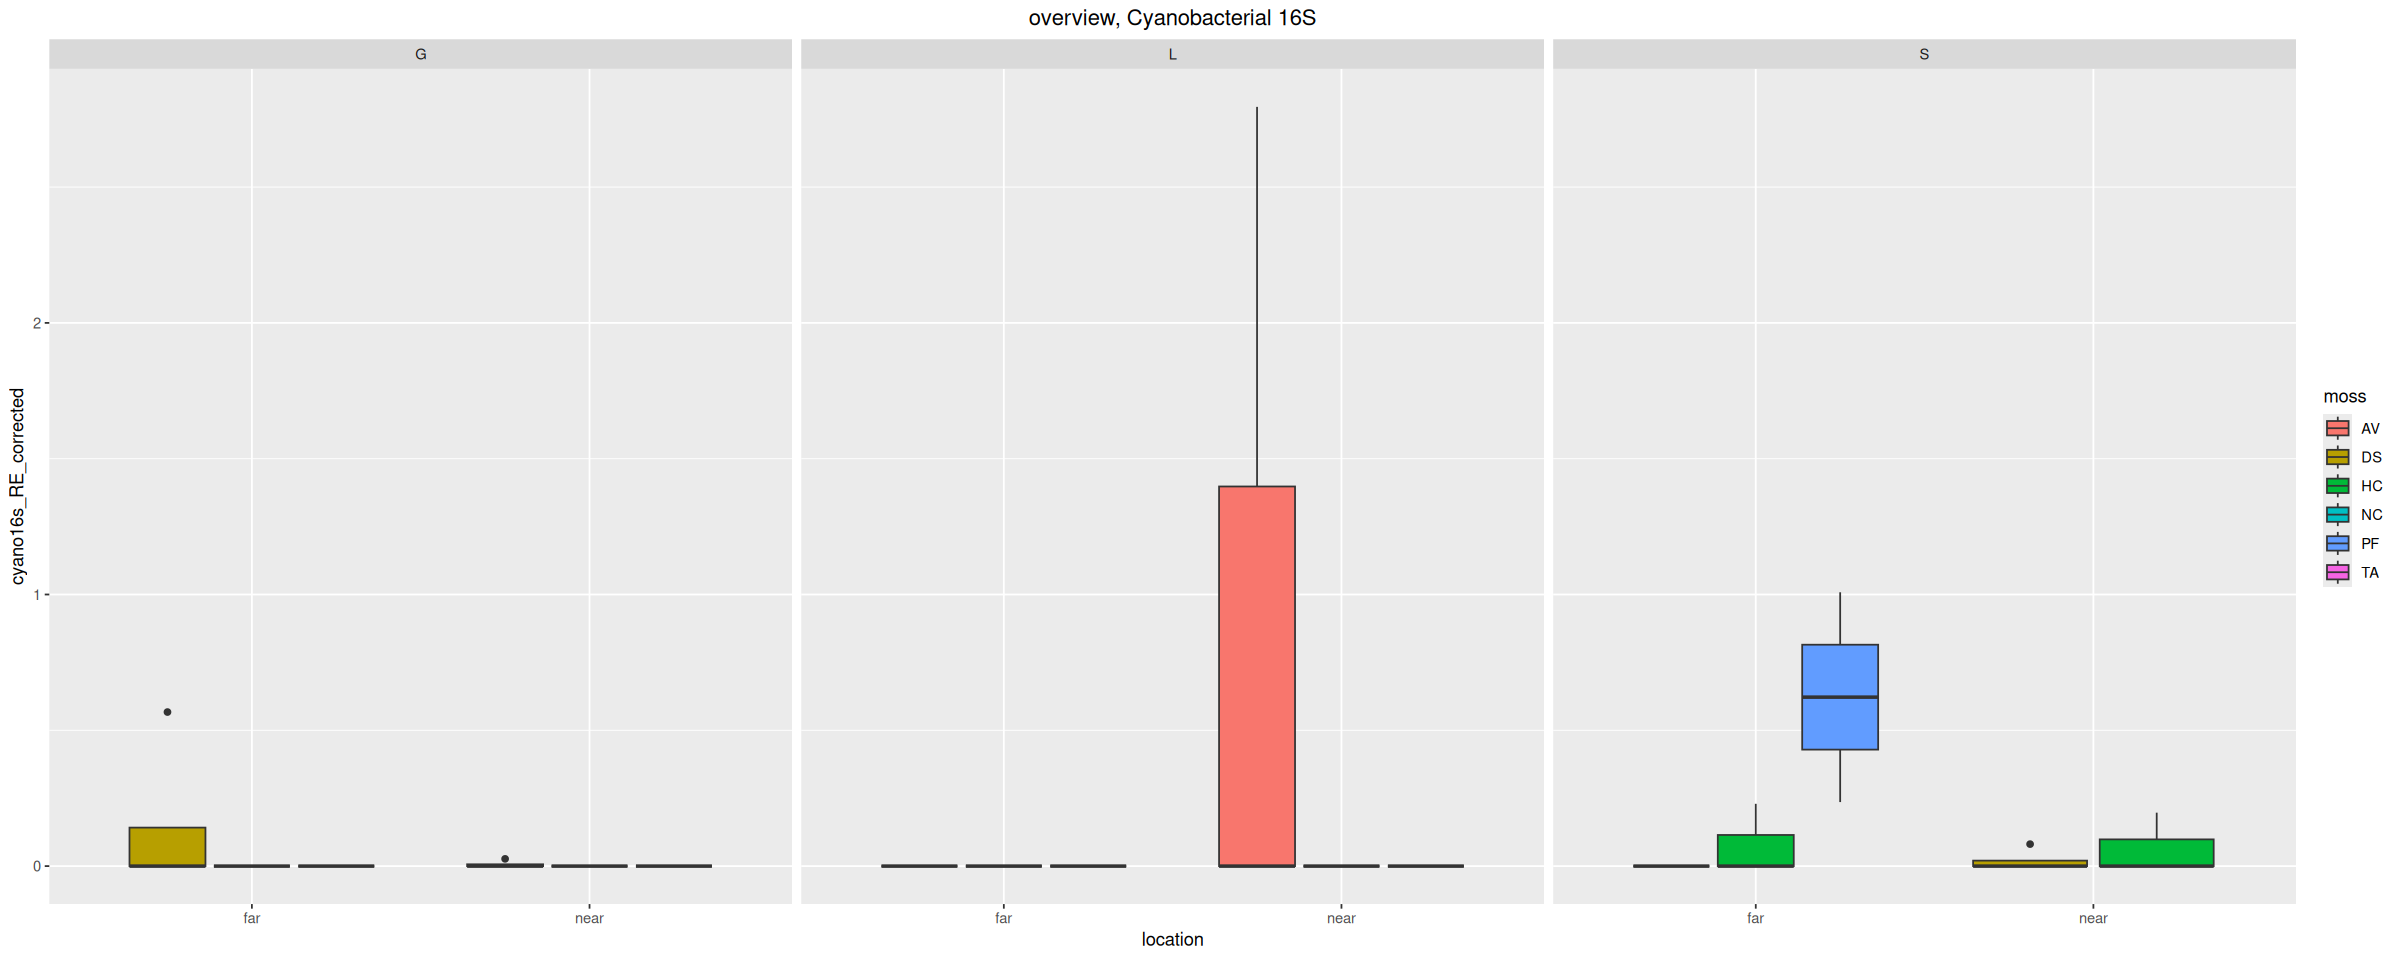

In [143]:
qPCRres <- read.csv("qPCRresults.csv", row.names=1)
cyano16s_overview <- ggplot(qPCRres, aes(x=location, y=cyano16s_RE_corrected, fill=moss)) +
                        geom_boxplot() + 
                        facet_grid(. ~ rock) +
                        ggtitle("overview, Cyanobacterial 16S") + 
                        theme(plot.title = element_text(hjust = 0.5))
cyano16s_overview


Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`).”


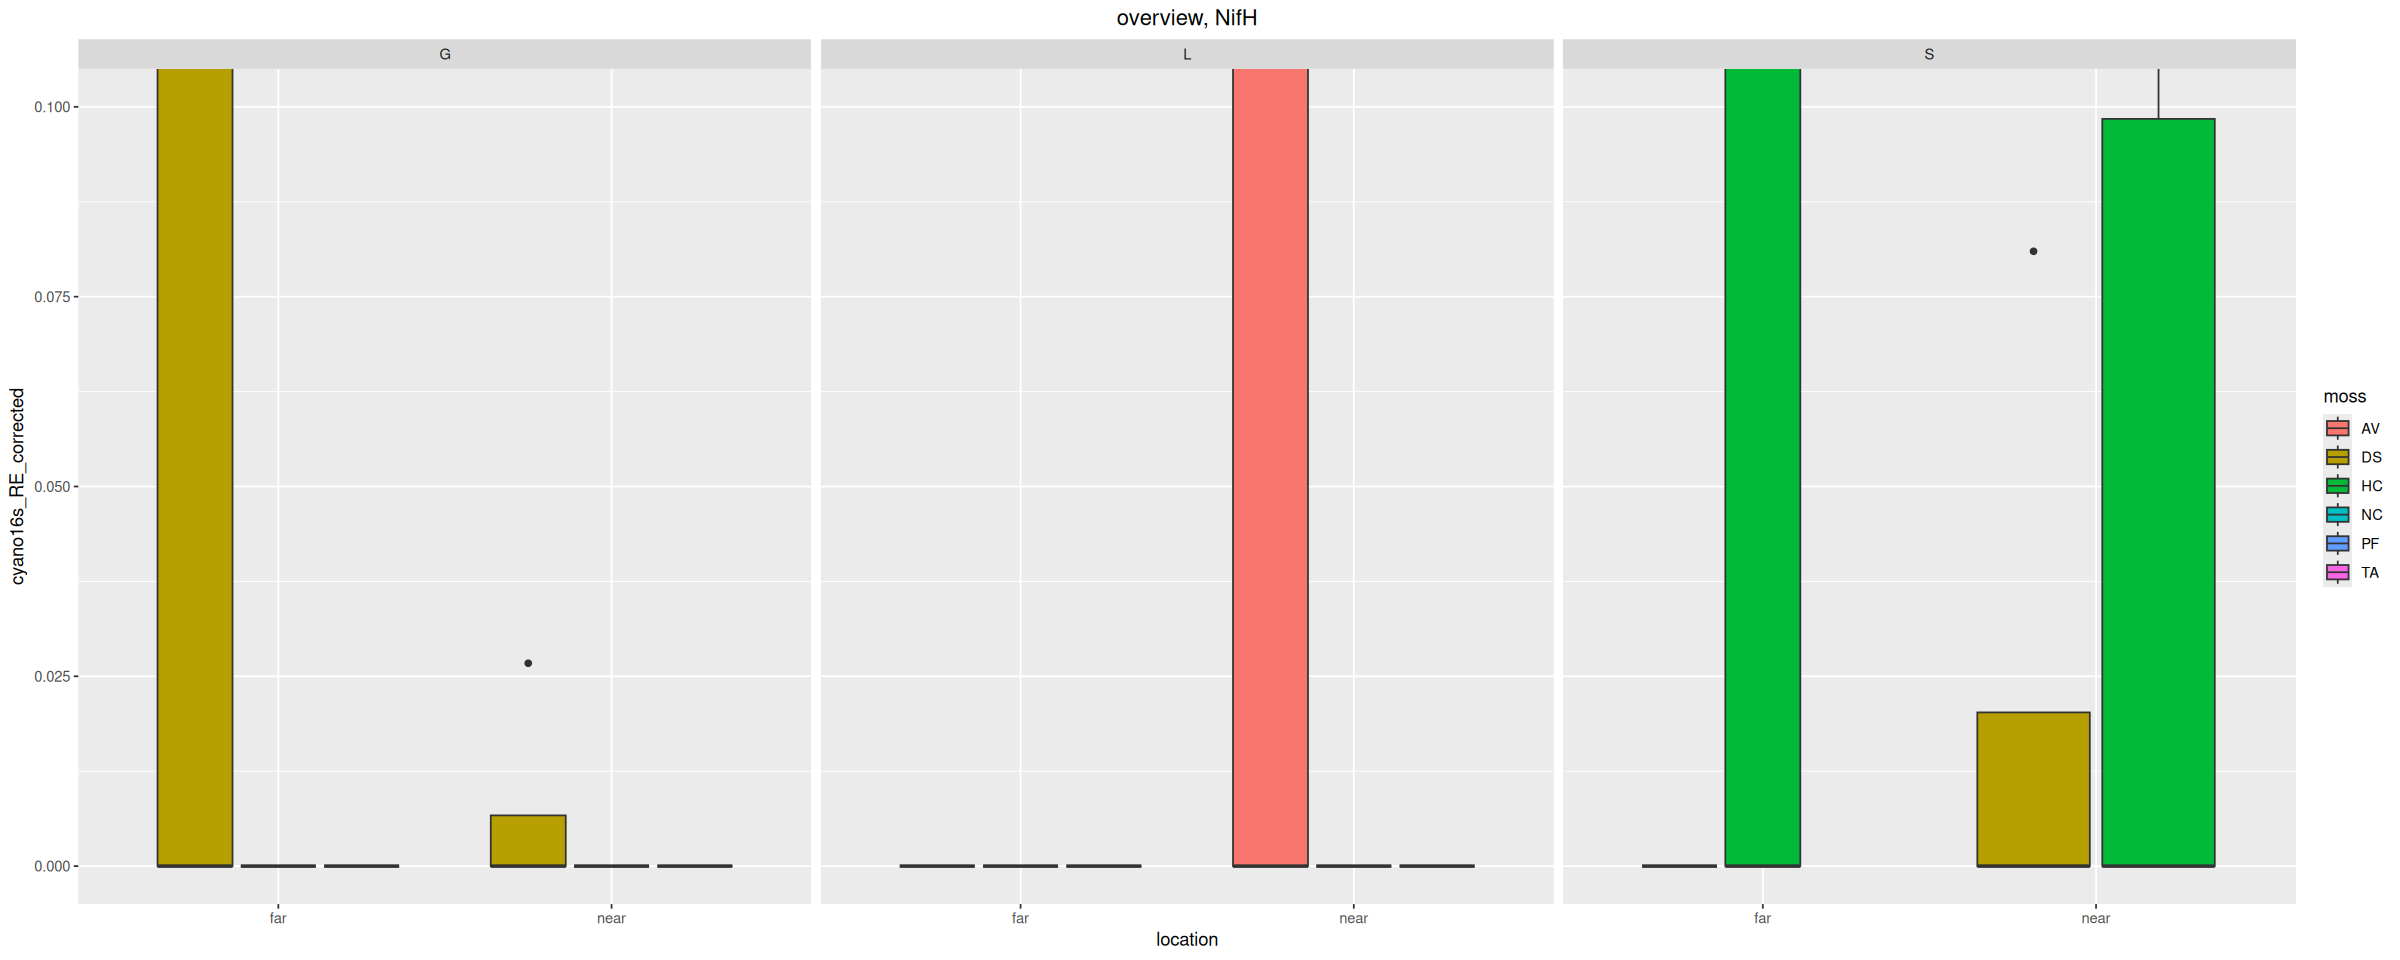

In [134]:
cyano16s_overview + coord_cartesian(ylim=c(0, .1))

Unlike nifH, we have a lot of zeroes. Only four species of moss showed positive for the presence of cyanobacteria (AV, DS, PF, HC), and even these often reported zero values. Make a table:

In [153]:
## get down to just complete data for cyano16s 
cyanoPA <- qPCRres[,c("subsite","location","rock","moss","cyano16s_RE_corrected")]
cyanoPA <- cyanoPA[complete.cases(cyanoPA),]
## create PA column:
cyanoPA['PA'] <- 0
cyanoPA[cyanoPA$cyano16s_RE_corrected > 0, "PA"] <- 1

## make a table to show zeroes and non-zeros for cyanobacterial 16S
table(cyanoPA$PA, cyanoPA$moss)

   
    AV DS HC NC PF TA
  0  6 12 12  8  5  9
  1  1  3  2  0  2  0

<i>Thamnobryum</i> and <i>Neckera</i> recorded no presence of cyanobacteria. 

Given the shape of these data, seems very unlikely to meaningful, but run the same tests as per nifH:


	Bartlett test of homogeneity of variances

data:  qPCRres$cyano16s_RE_corrected by qPCRres$location
Bartlett's K-squared = 19.543, df = 1, p-value = 9.838e-06


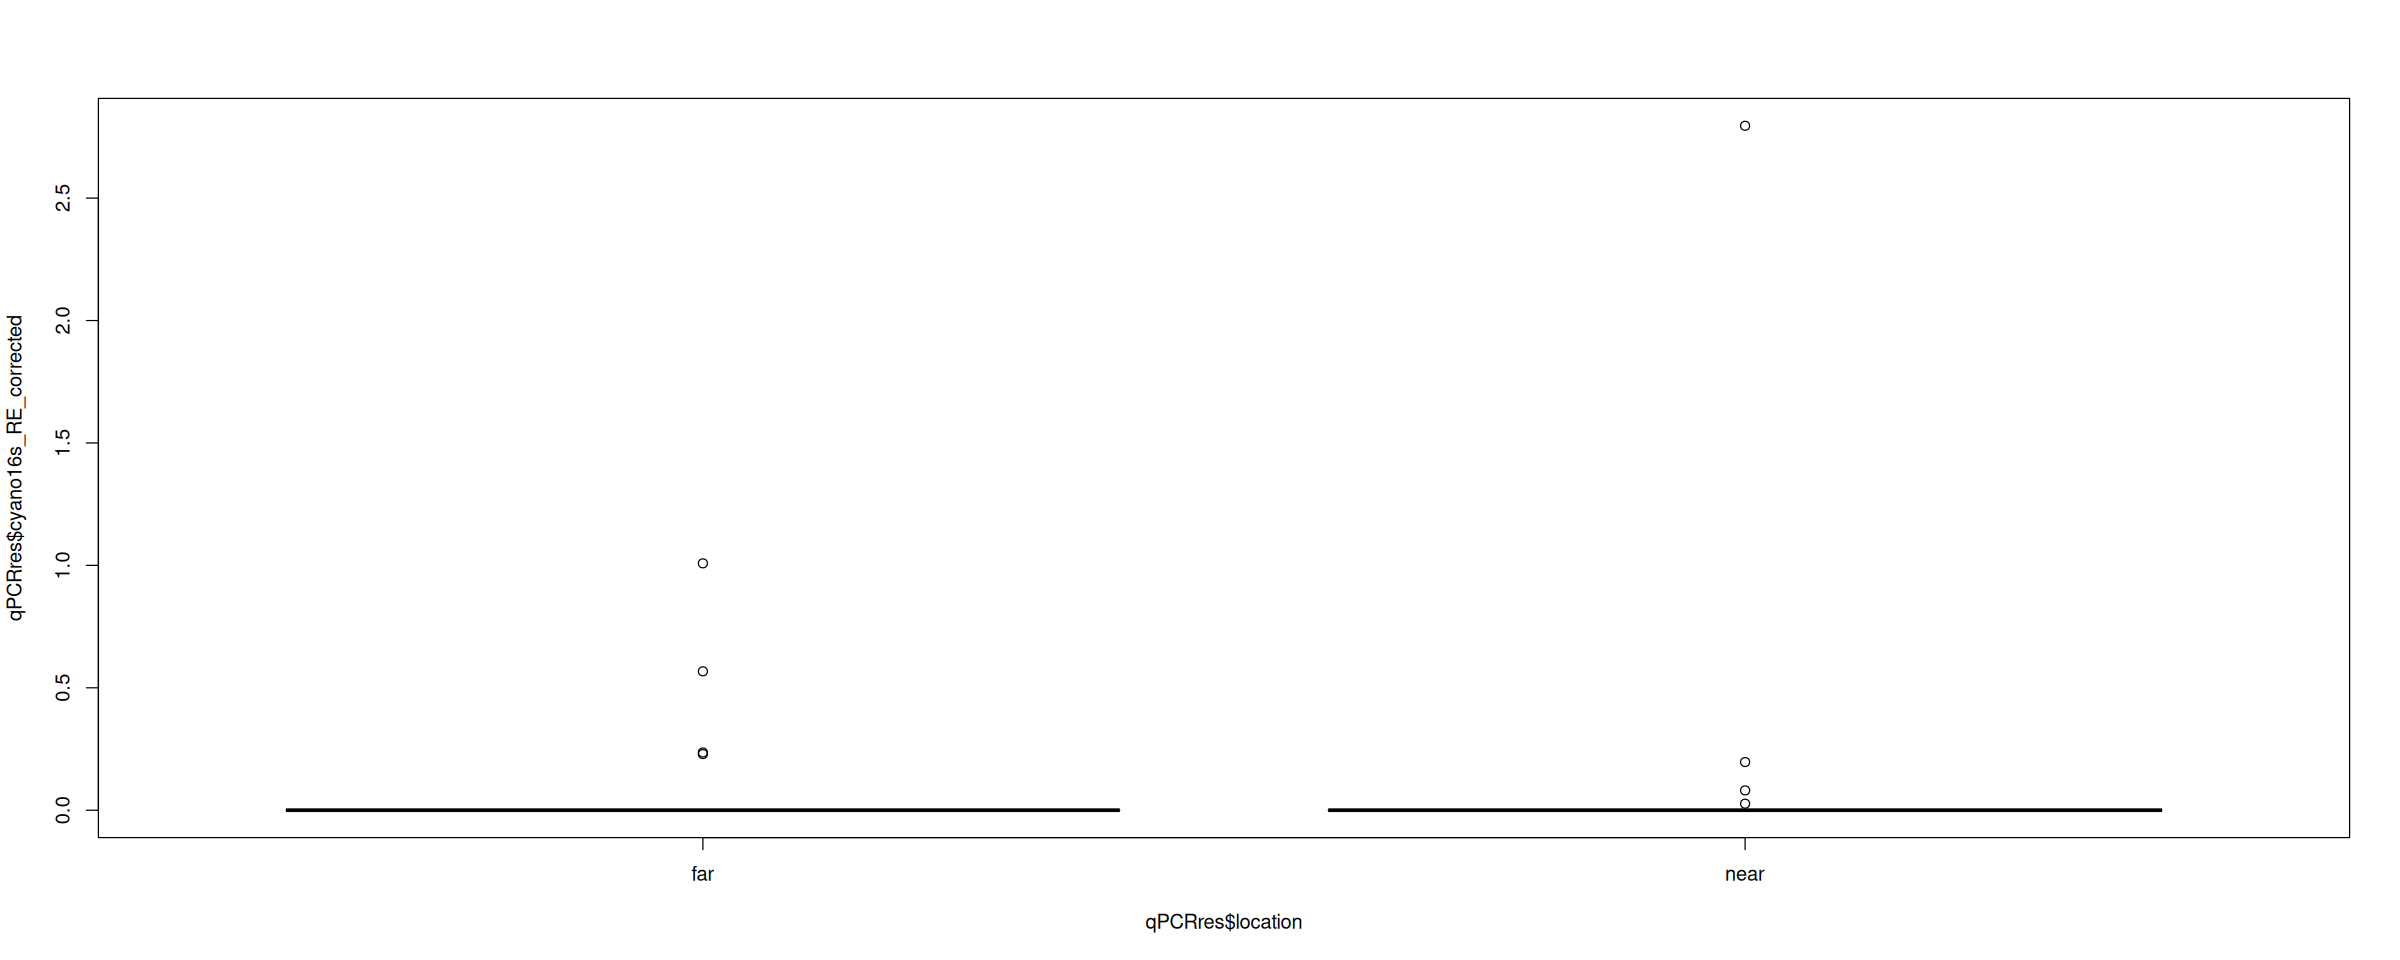

In [135]:
near_cyano16s_RE <- qPCRres[qPCRres$location == "near","cyano16s_RE_corrected"]
far_cyano16s_RE <- qPCRres[qPCRres$location == "far","cyano16s_RE_corrected"]
boxplot(qPCRres$cyano16s_RE_corrected ~ qPCRres$location) ## slighter higher RE in near samples
bartlett.test(qPCRres$cyano16s_RE_corrected ~ qPCRres$location)

In [136]:
t.test(x=near_nifH_RE,y=far_nifH_RE,
       alternative = "greater",
       mu = 0, 
       paired = TRUE,
       var.equal = FALSE,
       conf.level = 0.95)


	Paired t-test

data:  near_nifH_RE and far_nifH_RE
t = 0.81097, df = 34, p-value = 0.2115
alternative hypothesis: true mean difference is greater than 0
95 percent confidence interval:
 -0.002990595          Inf
sample estimates:
mean difference 
    0.002756128 


Linear model:

In [137]:
summary(lm(cyano16s_RE_corrected  ~ location  + moss + rock, data = qPCRres))


Call:
lm(formula = cyano16s_RE_corrected ~ location + moss + rock, 
    data = qPCRres)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.43235 -0.12134 -0.02567  0.03209  2.36304 

Coefficients: (1 not defined because of singularities)
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)   0.37458    0.15242   2.458   0.0174 *
locationnear  0.05776    0.10041   0.575   0.5676  
mossDS       -0.41104    0.18799  -2.186   0.0333 *
mossHC       -0.41954    0.18808  -2.231   0.0300 *
mossNC       -0.40347    0.20035  -2.014   0.0492 *
mossPF       -0.25262    0.21021  -1.202   0.2349  
mossTA       -0.40668    0.19538  -2.081   0.0423 *
rockL              NA         NA      NA       NA  
rockS         0.10853    0.13217   0.821   0.4153  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3869 on 52 degrees of freedom
  (14 observations deleted due to missingness)
Multiple R-squared:  0.1222,	Adjusted R-squared:  0.004076 

So with a classical regression, we don't pick up a strong signal from the location of the fern rhizome as a predictor of cyanobacterial abundance, just moss species. But let's switch gears a bit with our methods...

<a id="pseudocount"></a>
### Pseudo-count approach to cyanobacterial 16S data

But from here let's begin to take a pseudo-count approach. As explained above, we included the cyanobacterial 16S rRNA gene to as a way to survey for the presence of cyanobacteria, rather than as an estimate of their potential for nitrogen fixation, which was the goal with nifH. The distributions we see above are in-line with typical count data - lots of zeroes and rarely-sighted organisms, long tails/outliers possibly indicating locally abundant organisms, etc. 

In [162]:
options(repr.plot.width = 8, repr.plot.height = 4)

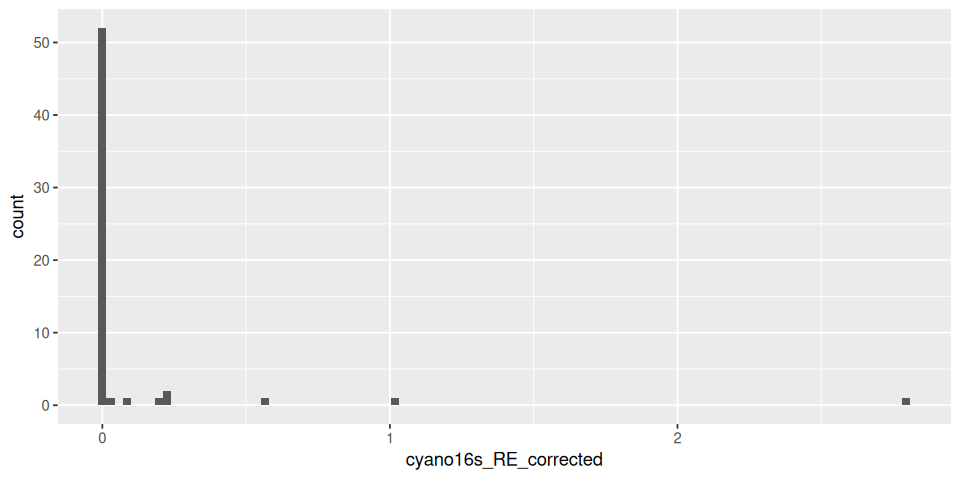

In [163]:
ggplot(cyanoPA, aes(cyano16s_RE_corrected)) + geom_histogram(bins=100)

To go forward with a count-data analysis, I will convert to pseudo-count data:

In [156]:
cyanoPA['REasCount'] <- round(cyanoPA$cyano16s_RE_corrected * 1000)
cyanoPA[1:5,c('cyano16s_RE_corrected','REasCount')]

,cyano16s_RE_corrected,REasCount
,<dbl>,<dbl>
B09,0.00000000,0
D09,0.00000000,0
F09,0.00000000,0
H09,0.56721535,567
A09,0.02671924,27


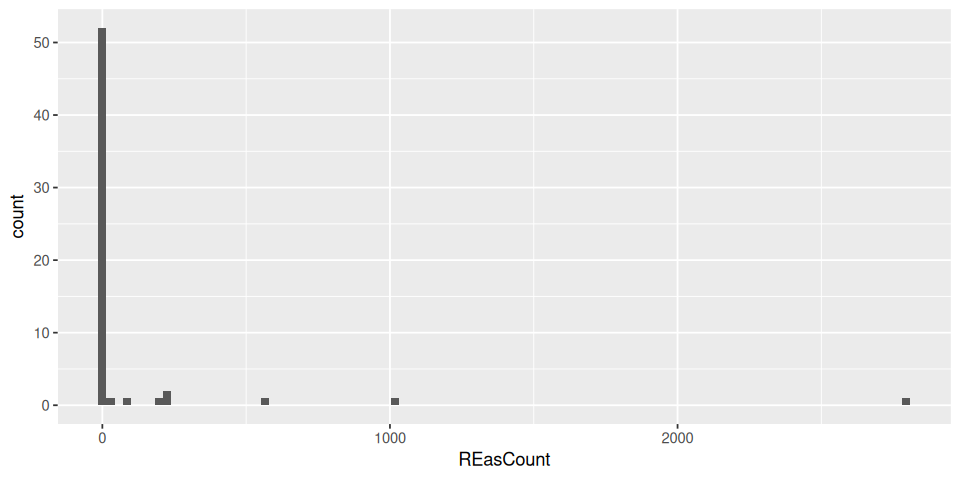

In [164]:
ggplot(cyanoPA, aes(REasCount)) + geom_histogram(bins=100)

Then we'll build zero-inflated poisson (ZIP) models. Justification: ZIPs are a better tool for these kind of data where non-observations (one kind of zero) can be created by other processes than extremely-low, basically-zero abundances. Based on our other microscopic studies of these cyanobacteria, we know that they are fairly rarely detectable (visible), but when observed they often reach very high local abundances. Their presence/absence in a sample is highly stochastic, and as much as they are predictible, they are also a result of dozens of ecological predictors we don't have data for, so this is a kind of latent process that creates most of the zeroes in our data. We want to focus on the patterns in the observations we do have. ZIP models let us do this - the zero-creation process is modeled one way, the abundances or number or positive observations can be modeled in a different sub-model.

So reformulating our statistical test for the effect of near/far location of fern rhizomes as a predictor:

In [165]:
summary(zeroinfl(REasCount ~ location, data = cyanoPA))


Call:
zeroinfl(formula = REasCount ~ location, data = cyanoPA)

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.3919 -0.3919 -0.3918 -0.3918 10.2094 

Count model coefficients (poisson with log link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   6.23441    0.02214  281.59   <2e-16 ***
locationnear  0.41845    0.02851   14.68   <2e-16 ***

Zero-inflation model coefficients (binomial with logit link):
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.872e+00  5.371e-01   3.485 0.000492 ***
locationnear 1.471e-08  7.596e-01   0.000 1.000000    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Number of iterations in BFGS optimization: 7 
Log-likelihood: -3477 on 4 Df

Here the model picks up on some sort of effect by distance to rhizome, as far as abundance of cyanobacterial abundance. If we add in mosses, we can see why:

In [166]:
## get rid of mosses that had zero cyanobacterial 16S reads at all, they cause singularity 
cyanoPA_noZeroMossSpp <- cyanoPA[cyanoPA$moss != "NC" & cyanoPA$moss != "TA", ]

summary(zeroinfl(REasCount ~ location + moss, data = cyanoPA_noZeroMossSpp))


Call:
zeroinfl(formula = REasCount ~ location + moss, data = cyanoPA_noZeroMossSpp)

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.6425 -0.4976 -0.4127 -0.4002  6.1925 

Count model coefficients (poisson with log link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   9.34584    0.07063  132.33   <2e-16 ***
locationnear -1.41025    0.06805  -20.73   <2e-16 ***
mossDS       -3.22867    0.06269  -51.50   <2e-16 ***
mossHC       -3.50980    0.07548  -46.50   <2e-16 ***
mossPF       -2.91290    0.07610  -38.27   <2e-16 ***

Zero-inflation model coefficients (binomial with logit link):
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   1.823101   1.135602   1.605    0.108
locationnear -0.072057   0.794067  -0.091    0.928
mossDS       -0.397981   1.261065  -0.316    0.752
mossHC        0.005157   1.324206   0.004    0.997
mossPF       -0.875651   1.366402  -0.641    0.522
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 



We can see that mossAV (<i>Anomodon viticulosus</i>, which is the intercept) is the reason, again. It shows a strong near/far contrast. The other moss species actually reverse this pattern (as we see in the boxplots above). So I still don't really believe that location of fern rhizome is a really useful predictor.

<a id=cyano16sRockMoss></a>
### Rock type and Moss species

In [138]:
qPCRres <- read.csv("qPCRresults.csv", row.names=1)

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“R

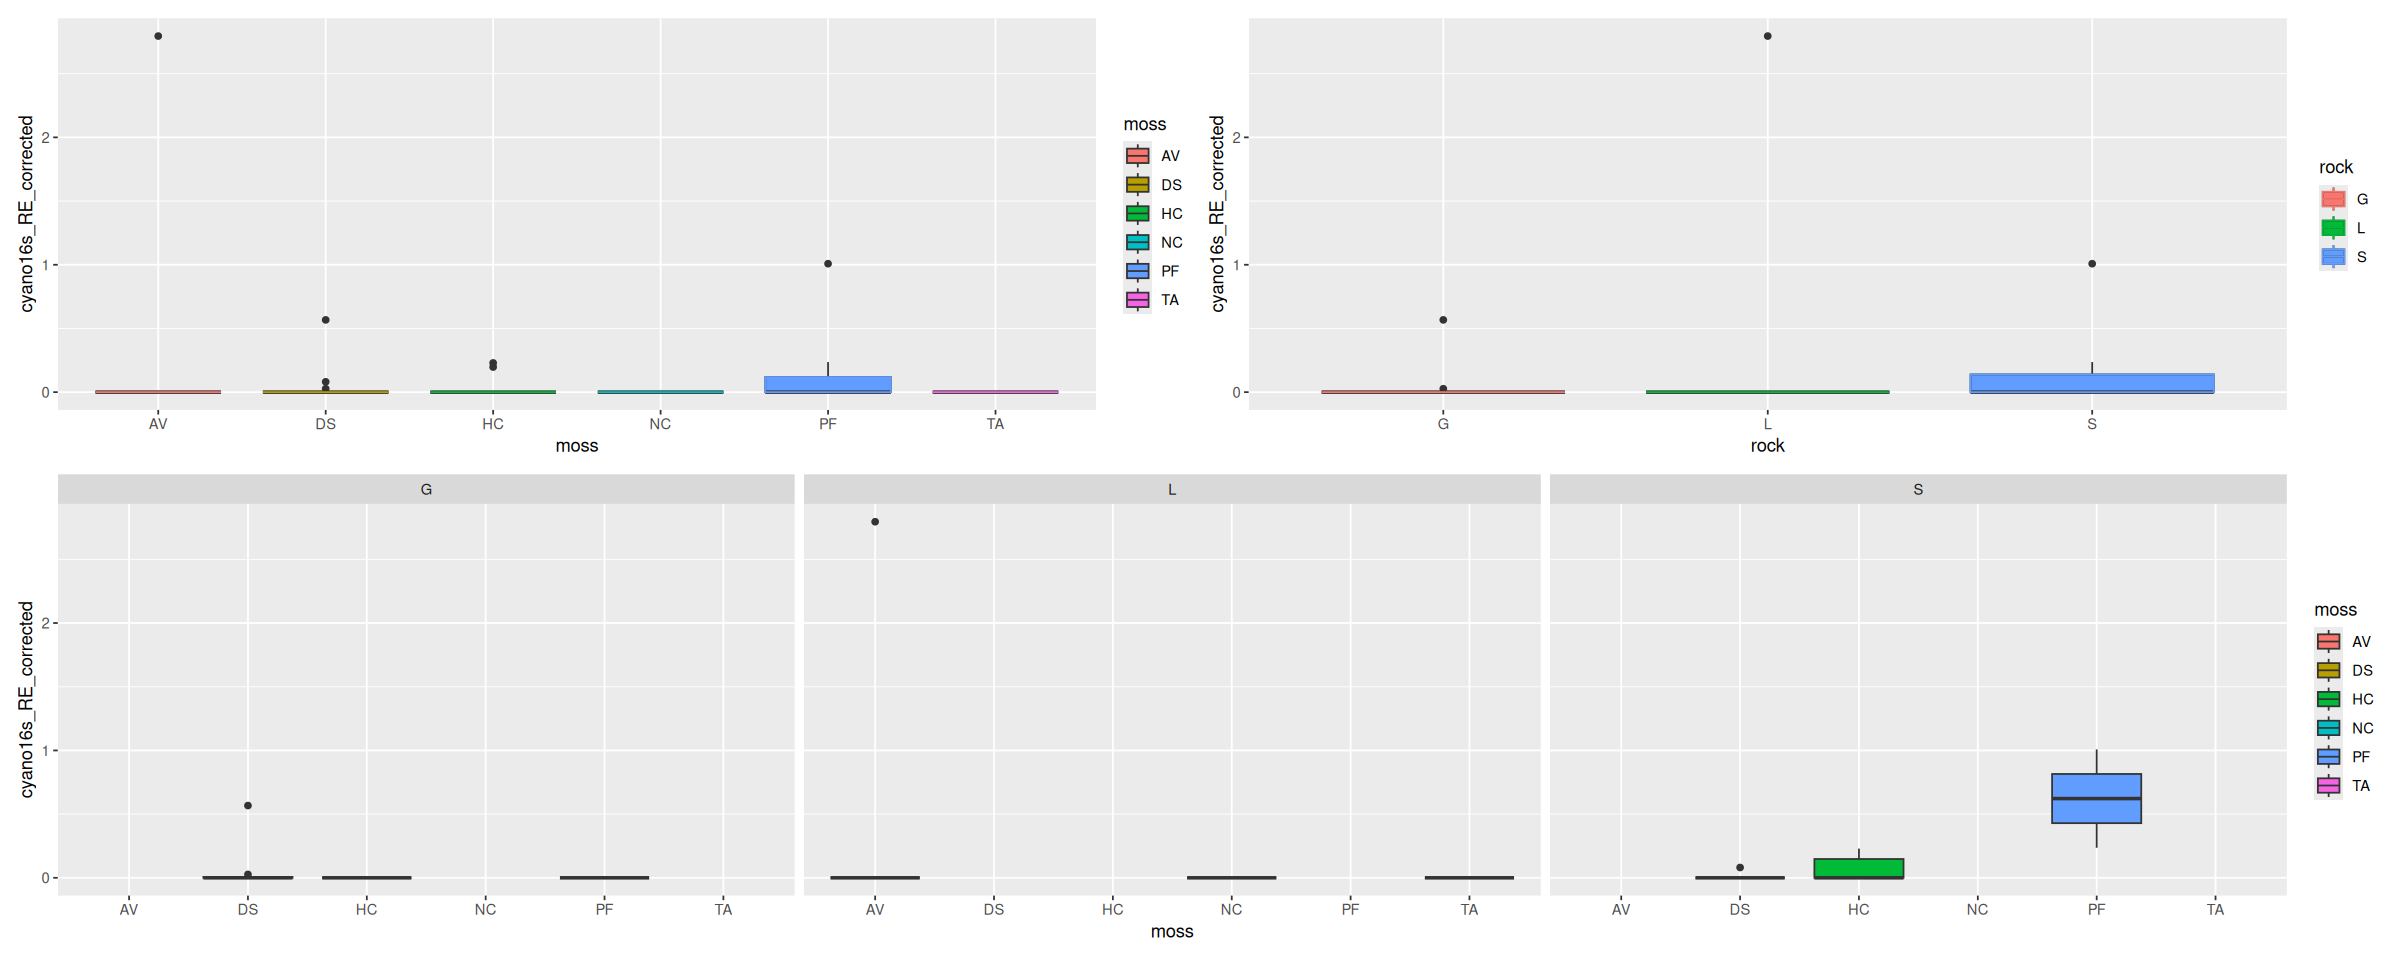

In [139]:
cyano16s_moss_box <- ggplot(qPCRres, aes(x=moss, y=cyano16s_RE_corrected, fill=moss)) +
                        geom_boxplot() +
                        geom_boxplot(aes(col=moss), fatten=NULL, fill=NA,
                                     coef=0, outlier.shape=NA,show.legend = F)

cyano16s_rock_box <- ggplot(qPCRres, aes(x=rock, y=cyano16s_RE_corrected, fill=rock)) +
                        geom_boxplot() +
                        geom_boxplot(aes(col=rock), fatten=NULL, fill=NA,
                                     coef=0, outlier.shape=NA,show.legend = T)


cyano16s_rock_moss_box <- ggplot(qPCRres, aes(x=moss, y=cyano16s_RE_corrected, fill=moss)) +
                        geom_boxplot() +
                        facet_grid(. ~ rock)

 (cyano16s_moss_box | cyano16s_rock_box) / cyano16s_rock_moss_box


Finding a cyanobacteria is a relatively rare thing here. Each moss had rocktype originally had either 16 or 8 replicates, depending on moss species: 1 or 2 rocktypes * (4 near + 4 far), though lots were lost to failed reactions. There are positive (non-zero) observations in 4 out of 6 mosses, but in each moss it looks like the cyanos were positively observed just a few times from each of the 8 or 16 replicates. For instance, it looks like AV had a positive cyanobacterial observation only once, but that it was very abundant in that sample. 

In [167]:
table(cyanoPA$PA, cyanoPA$moss)

   
    AV DS HC NC PF TA
  0  6 12 12  8  5  9
  1  1  3  2  0  2  0

We can't model the effect of rock type and moss together, as mentioned above, because there are several clean separations here that introduce singularity to the models - AV, NC and TA were only sampled in limestone, and DS, HC, and PF were only sampled from granite and sandstone. So for the moment I'll make two models, one for rock type and one for mosses. 

In [169]:
## get rid of mosses that showed no cyanobact 16S at all, they also cause singularity:
cyanoPA_noZeroMossSpp <- cyanoPA[cyanoPA$moss != "NC" & cyanoPA$moss != "TA", ]
summary(zeroinfl(REasCount ~ moss, data = cyanoPA_noZeroMossSpp))


Call:
zeroinfl(formula = REasCount ~ moss, data = cyanoPA_noZeroMossSpp)

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.6317 -0.4986 -0.4082 -0.4071  5.7840 

Count model coefficients (poisson with log link):
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  7.93559    0.01892  419.54   <2e-16 ***
mossDS      -2.51949    0.04289  -58.75   <2e-16 ***
mossHC      -2.57429    0.05201  -49.49   <2e-16 ***
mossPF      -1.50265    0.03408  -44.09   <2e-16 ***

Zero-inflation model coefficients (binomial with logit link):
              Estimate Std. Error z value Pr(>|z|)  
(Intercept)  1.792e+00  1.080e+00   1.659   0.0971 .
mossDS      -4.055e-01  1.258e+00  -0.322   0.7473  
mossHC       5.283e-08  1.323e+00   0.000   1.0000  
mossPF      -8.755e-01  1.366e+00  -0.641   0.5217  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Number of iterations in BFGS optimization: 11 
Log-likelihood: -693.4 on 8 Df

As before, AV (intercept) is the star of show. <i>Polytrichum formosum</i> (PF) is next in line as the next most abundant. We can't really confidently say that any of the moss types showed more/less zeroes. 

A model for rocktype:

In [172]:
summary(zeroinfl(REasCount ~ rock, data = cyanoPA))


Call:
zeroinfl(formula = REasCount ~ rock, data = cyanoPA)

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.7056 -0.3238 -0.2122 -0.2085  6.1677 

Count model coefficients (poisson with log link):
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  5.69373    0.04103  138.77  < 2e-16 ***
rockL        2.24186    0.04518   49.62  < 2e-16 ***
rockS        0.16477    0.04748    3.47  0.00052 ***

Zero-inflation model coefficients (binomial with logit link):
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)   2.2513     0.7434   3.028  0.00246 **
rockL         0.8842     1.2634   0.700  0.48401   
rockS        -1.5581     0.9234  -1.687  0.09152 . 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Number of iterations in BFGS optimization: 12 
Log-likelihood: -995.4 on 6 Df

Here granite is given as the intercept, and Limestone and Sandsone are observed to host a higher count of cyanobacterial 16S. However, the greatest number of zeroes is limestone. So even though limestone has the highest modeled abundances of cyanobacteria, it is also the one where one is least likely to observe cyanobacteria. 